In [26]:
# ── Cell 1 : Imports ───────────────────────────────────────────────────────────
import json
import time
import datetime

import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from matplotlib.lines import Line2D

import liesel.model as lsl
import liesel.goose as gs
from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 9)

In [ ]:
# ── Cell 2 : Data Loading Function ────────────────────────────────────────────
def load_margarine_data(filepath):
    """Loads and preprocesses the margarine dataset."""
    with open(filepath, 'r') as f:
        raw_data = json.load(f)
    
    X_list, y_list, Z_list, unit_indices = [], [], [], []
    
    n_alts_orig = 10
    kept_alts_1based = np.array([1, 2, 3, 4, 5, 7])
    kept_alts_0based = kept_alts_1based - 1 
    p = len(kept_alts_0based) 
    y_mapping = {val: idx for idx, val in enumerate(kept_alts_1based)}
    unit_idx_counter = 0
    
    for respondent in raw_data:
        X_raw = np.array(respondent['X'])
        y_raw = np.array(respondent['y'])
        
        if y_raw.ndim == 0:
            y_raw = np.atleast_1d(y_raw)
        
        n_choice_occasions_orig = len(y_raw)
        n_params_orig = X_raw.shape[1]
        X_reshaped = X_raw.reshape((n_choice_occasions_orig, n_alts_orig, n_params_orig))
        
        valid_occasions = np.isin(y_raw, kept_alts_1based)
        y_filtered = y_raw[valid_occasions]
        X_filtered = X_reshaped[valid_occasions]
        
        n_obs = len(y_filtered)
        if n_obs < 5:
            continue
            
        Z_raw = np.array(respondent.get('Z_raw', [1.0, 1.0]))
        Z_list.append(Z_raw)
        y_recoded = np.array([y_mapping[val] for val in y_filtered])
        X_new = np.zeros((n_obs, p, p))
        
        for r in range(n_obs):
            orig_prices = X_filtered[r, kept_alts_0based, 9]
            log_prices = np.log(orig_prices)
            X_new[r, 1:, 0:5] = np.eye(5)
            X_new[r, :, 5] = log_prices
            
        X_list.append(X_new)
        y_list.append(y_recoded)
        unit_indices.extend([unit_idx_counter] * n_obs)
        unit_idx_counter += 1

        Z_arr = np.array(Z_list)
        Z_arr[:, 0] = np.log(Z_arr[:, 0]) # Log Income

        # ── PER ROSSI: Center the data, but DO NOT add an intercept ──────────
        Z_arr[:, 0] -= np.mean(Z_arr[:, 0]) # De-mean Log Income
        Z_arr[:, 1] -= np.mean(Z_arr[:, 1]) # De-mean Family Size
        Z_final = Z_arr # No vector of ones appended

    return {
        "X": jnp.array(np.concatenate(X_list, axis=0)),
        "y": jnp.array(np.concatenate(y_list, axis=0)),
        "Z": jnp.array(Z_final),
        "unit_idx": jnp.array(unit_indices),
        "n_units": unit_idx_counter,
        "n_params": p,
        "n_z": Z_final.shape[1] # This will now correctly be 2 instead of 3
    }

In [17]:
# ==========================================
# 2. FACTORY FUNCTIONS
# ==========================================
def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df,
        scale_tril=scale_tril,
        input_output_cholesky=True,
        validate_args=False
    )

def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )

In [22]:
# ── Cell 3 : Model Builder & Factories ────────────────────────────────────────
def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df,
        scale_tril=scale_tril,
        input_output_cholesky=True,
        validate_args=False
    )

def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )

def build_mixture_hmnl_model(
        data_dict,
        A_delta=0.01,
        a_mu=0.01,
        dirichlet_a=5.0
):
    """
    HMNL with mixture-of-normals heterogeneity.
    Prior structure matches bayesm::rhierMnlRwMixture.
    """
    n_params = int(data_dict["n_params"])
    n_units  = int(data_dict["n_units"])
    K_comp   = int(data_dict["K"])
    has_Z    = data_dict.get("Z") is not None

    # ── Wishart prior ─────────────────────────────────────────────────────────
    nu          = float(n_params + 3)
    V           = nu * jnp.eye(n_params)
    Vinv_chol   = jnp.linalg.cholesky(jnp.linalg.inv(V))
    Vinv_chol_K = jnp.broadcast_to(Vinv_chol[None], (K_comp, n_params, n_params))

    # ── pvec ~ Dirichlet ──────────────────────────────────────────────────────
    pvec = lsl.Var.new_param(
        value=jnp.ones(K_comp) / K_comp,
        distribution=lsl.Dist(tfd.Dirichlet,
                               concentration=jnp.ones(K_comp) * dirichlet_a),
        name="pvec"
    )
    pvec_latent = pvec.transform(tfb.SoftmaxCentered(), name="pvec_latent")

    # ── Sigma_k^{-1} ~ Wishart via Cholesky ──────────────────────────────────
    sigma_inv_chol_k = lsl.Var.new_param(
        value=jnp.broadcast_to(jnp.eye(n_params)[None], (K_comp, n_params, n_params)),
        distribution=lsl.Dist(
            make_wishart,
            df=jnp.full(K_comp, nu),
            scale_tril=Vinv_chol_K
        ),
        name="sigma_inv_chol_k"
    )
    sigma_inv_chol_k_latent = sigma_inv_chol_k.transform(
        tfb.FillScaleTriL(), name="sigma_inv_chol_k_latent"
    )

    # ── mu_k | Sigma_k ~ N(0, Sigma_k / a_mu) ────────────────────────────────
    mu_prec_factor_k = lsl.Var.new_calc(
        lambda L: jnp.sqrt(a_mu) * L,
        L=sigma_inv_chol_k,
        name="mu_prec_factor_k"
    )
    mu_k = lsl.Var.new_param(
        value=jnp.zeros((K_comp, n_params)),
        distribution=lsl.Dist(
            make_mvn_precision,
            loc=jnp.zeros(n_params),
            precision_factor=mu_prec_factor_k
        ),
        name="mu_k"
    )

    # ── Delta ~ N(0, (1/A_delta) * I) ────────────────────────────────────────
    if has_Z:
        n_demos           = int(data_dict["Z"].shape[1])
        Z_var             = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
        Delta_prec_factor = jnp.sqrt(A_delta) * jnp.eye(n_params)

        Delta = lsl.Var.new_param(
            value=jnp.zeros((n_demos, n_params)),
            distribution=lsl.Dist(
                make_mvn_precision,
                loc=jnp.zeros(n_params),
                precision_factor=Delta_prec_factor
            ),
            name="Delta"
        )
        z_delta = lsl.Var.new_calc(
            lambda z, d: z @ d, z=Z_var, d=Delta, name="z_delta"
        )

    # ── beta_i location: Z[i] @ Delta + mu_k  (n_units, K, n_params) ─────────
    if has_Z:
        beta_loc = lsl.Var.new_calc(
            lambda zd, mu: zd[:, None, :] + mu[None, :, :],
            zd=z_delta, mu=mu_k,
            name="beta_loc"
        )
    else:
        beta_loc = lsl.Var.new_calc(
            lambda mu: jnp.broadcast_to(mu[None, :, :], (n_units, K_comp, n_params)),
            mu=mu_k,
            name="beta_loc"
        )

    # Updated mixture function using precision factors
    def make_beta_mixture(pvec, locs, precision_factors):
        return tfd.MixtureSameFamily(
            mixture_distribution=tfd.Categorical(probs=pvec),
            components_distribution=tfde.MultivariateNormalPrecisionFactorLinearOperator(
                loc=locs,
                precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factors[None])
            )
        )

    # Updated beta_i definition
    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, n_params)),
        distribution=lsl.Dist(
            make_beta_mixture,
            pvec=pvec,
            locs=beta_loc,
            precision_factors=sigma_inv_chol_k  
        ),
        name="beta_i"
    )

    # ── Likelihood ────────────────────────────────────────────────────────────
    X_var         = lsl.Var.new_obs(data_dict["X"],        name="X_obs")
    idx_var       = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")
    beta_expanded = lsl.Var.new_calc(
        lambda b, idx: b[idx], b=beta_i, idx=idx_var, name="beta_expanded"
    )
    logits = lsl.Var.new_calc(
        lambda x, b: jnp.einsum("nij,nj->ni", x, b),
        x=X_var, b=beta_expanded,
        name="logits"
    )
    y_var = lsl.Var.new_obs(
        data_dict["y"],
        distribution=lsl.Dist(tfd.Categorical, logits=logits),
        name="y"
    )

    return lsl.Model([y_var])

In [23]:
# ── Cell 4 : Inference Engine ─────────────────────────────────────────────────
def run_mixture_inference(model, data_dict, chains=4, warmup=1000,
                          posterior=5000, seed=123):
    has_Z = data_dict.get("Z") is not None
    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)

    # Block 1: Hyperparameters
    eb.add_kernel(gs.NUTSKernel(
        ["pvec_latent", "mu_k", "sigma_inv_chol_k_latent"],
        mm_diag=True 
    ))
    
    # Block 2: Covariates
    if has_Z:
        eb.add_kernel(gs.NUTSKernel(["Delta"]))

    # Block 3: Individual level parameters
    eb.add_kernel(gs.NUTSKernel(["beta_i"], mm_diag=True))

    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print("Starting NUTS Sampling — Mixture HMNL...")
    engine = eb.build()
    engine.sample_all_epochs()
    return engine.get_results(), engine.get_results().get_posterior_samples()

In [25]:
# ── Cell 5 : Execution (Run Data, Build Model, Sample) ────────────────────────
print("Loading data...")
# Ensure "margarine_data.json" is in the same directory as the notebook
data_dict = load_margarine_data("margarine_data.json")

# Setup number of mixture components (K)
data_dict["K"] = 2 
k_dim = int(data_dict["n_params"])

print(f"Data Loaded: {data_dict['n_units']} units, {k_dim} parameters, {data_dict['n_z']} demographic vars")
print(f"Total Observations: {data_dict['y'].shape[0]}")
print(f"Mixture Components (K): {data_dict['K']}")

print("Building 2-component mixture HMNL model...")
hmnl_model = build_mixture_hmnl_model(
    data_dict, A_delta=0.01, a_mu=0.01, dirichlet_a=5.0
)
print("Model built successfully.")

# Run inference
start_time = time.time()
n_warmup = 1000
n_posterior = 2500

mcmc_results, posterior_samples = run_mixture_inference(
    hmnl_model, data_dict, chains=4, warmup=n_warmup, posterior=n_posterior, seed=123
)

end_time = time.time()
formatted_time = str(datetime.timedelta(seconds=int(end_time - start_time)))
print(f"Sampling finished in {formatted_time} (H:M:S)")

# Save Results
output_dir = "Data"
os.makedirs(output_dir, exist_ok=True)
pkl_filename = os.path.join(output_dir, "liesel_mixture_posterior_samples.pkl") 

print(f"Saving samples to {pkl_filename}...")
with open(pkl_filename, "wb") as f:
    pickle.dump(posterior_samples, f)
    
print("Samples saved successfully!")

Loading data...
Data Loaded: 313 units, 6 parameters, 3 demographic vars
Total Observations: 3405
Mixture Components (K): 2
Building 2-component mixture HMNL model...
Model built successfully.


liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS Sampling — Mixture HMNL...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:27<00:00,  9.16s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 6, 10, 6, 5 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 0, 2, 4, 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2, 3, 2, 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 333.12chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 6, 5, 2, 3 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 2, 2, 2, 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1, 1, 1, 1 / 25 transitions
liesel.goose.

Sampling finished in 0:18:02 (H:M:S)
Saving samples to Data\liesel_mixture_posterior_samples.pkl...
Samples saved successfully!


In [30]:
# ── Cell 5 : Label Switching — Pivotal Reordering Algorithm ───────────────────

def pra(xi_star, xi_draws):
    m, K_c, J = xi_draws.shape
    perms     = np.empty((m, K_c), dtype=int)
    relabeled = np.empty_like(xi_draws)
    for t in range(m):
        cost = np.sum(
            (xi_star[:, None, :] - xi_draws[t, None, :, :]) ** 2, axis=-1
        )
        _, perms[t] = linear_sum_assignment(cost)
        relabeled[t] = xi_draws[t, perms[t], :]
    return perms, relabeled


def apply_permutations(draws, perms):
    relabeled = np.empty_like(draws)
    for t in range(perms.shape[0]):
        relabeled[t] = draws[t, perms[t]]
    return relabeled


def resolve_label_switching(samples_dict, pivot_chain_idx=0):
    print("\nStarting Pivotal Reordering Algorithm (PRA)...")
    mu                           = samples_dict["mu_k"]
    n_chains, n_draws, K_c, n_p = mu.shape
    m                            = n_chains * n_draws

    mu_flat  = mu.reshape(m, K_c, n_p)
    xi_star  = np.mean(mu[pivot_chain_idx], axis=0)
    perms, relabeled_mu_flat = pra(xi_star, mu_flat)

    sorted_samples         = samples_dict.copy()
    sorted_samples["mu_k"] = relabeled_mu_flat.reshape(n_chains, n_draws, K_c, n_p)

    # Sigma
    sigma      = samples_dict["sigma_inv_chol_k_latent"]
    s_shape    = sigma.shape
    sigma_flat = sigma.reshape(m, K_c, *s_shape[3:])
    sorted_samples["sigma_inv_chol_k_latent"] = apply_permutations(
        sigma_flat, perms
    ).reshape(s_shape)

    # pvec: latent → simplex → permute
    pvec_simplex = np.array(
        tfb.SoftmaxCentered().forward(samples_dict["pvec_latent"])
    )
    pvec_flat = pvec_simplex.reshape(m, K_c)
    sorted_samples["pvec"] = apply_permutations(
        pvec_flat, perms
    ).reshape(n_chains, n_draws, K_c)

    print("Label switching resolved — all chains aligned.")
    return sorted_samples


posterior_samples_sorted = resolve_label_switching(
    posterior_samples, pivot_chain_idx=0
)


Starting Pivotal Reordering Algorithm (PRA)...
Label switching resolved — all chains aligned.



=== MCMC Convergence Summary ===

Plotting Cholesky Traces...


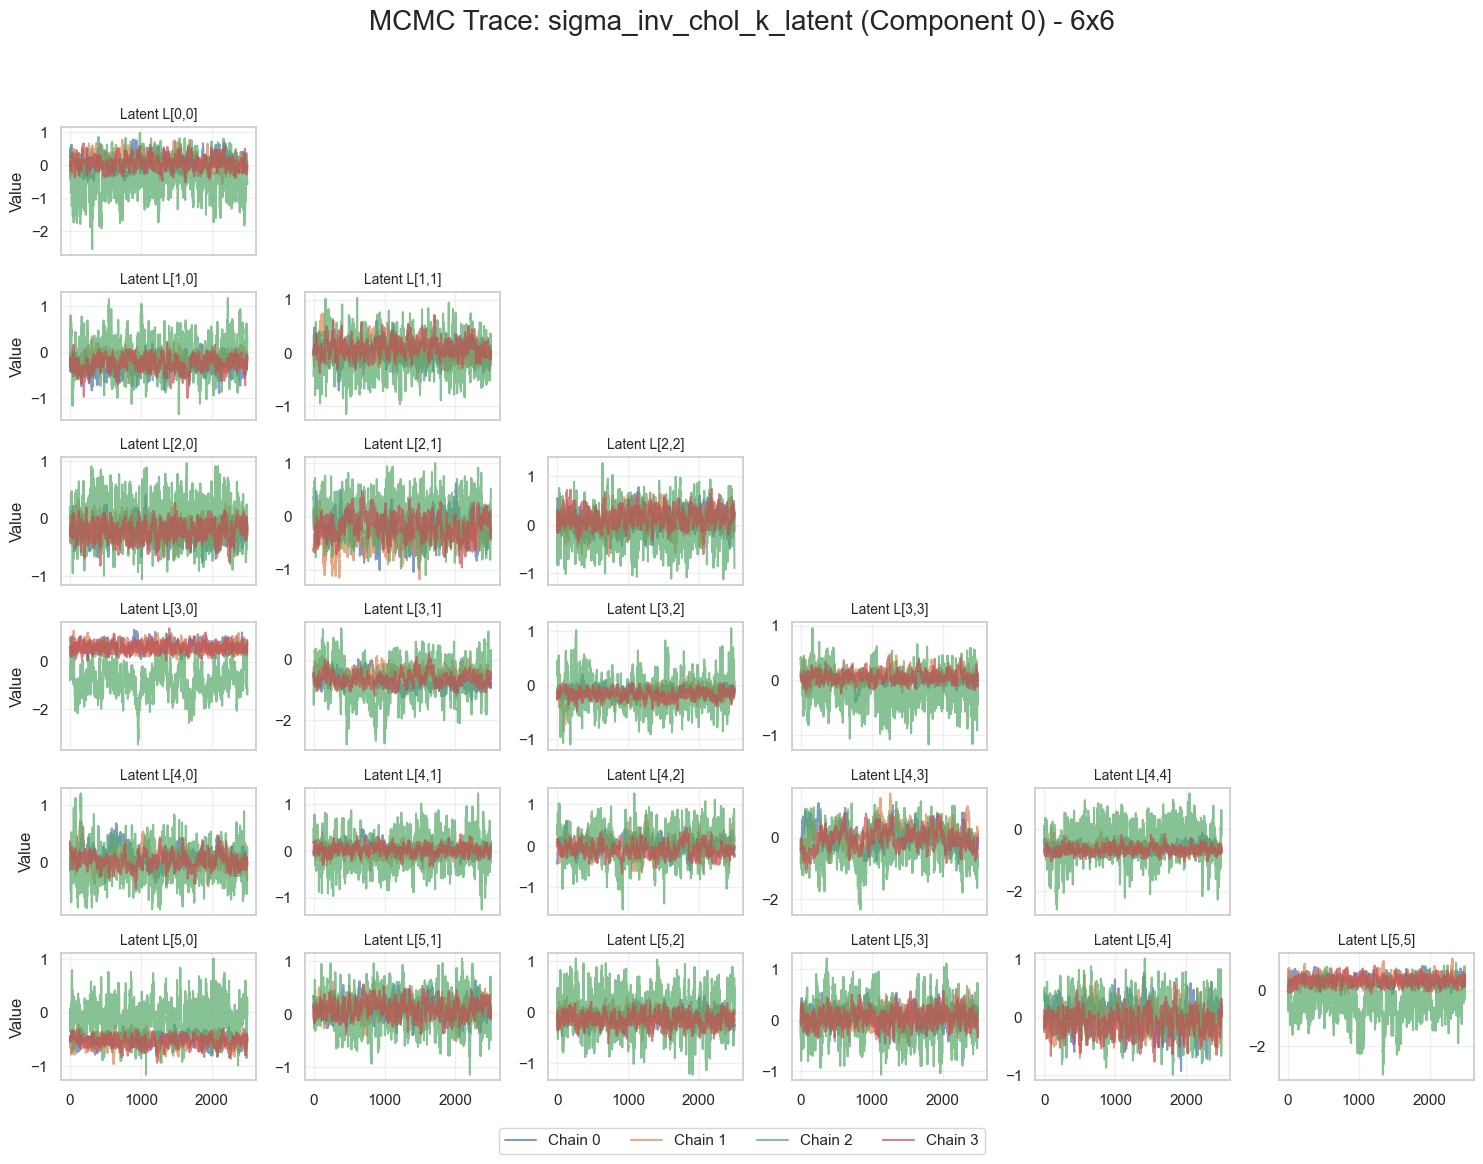

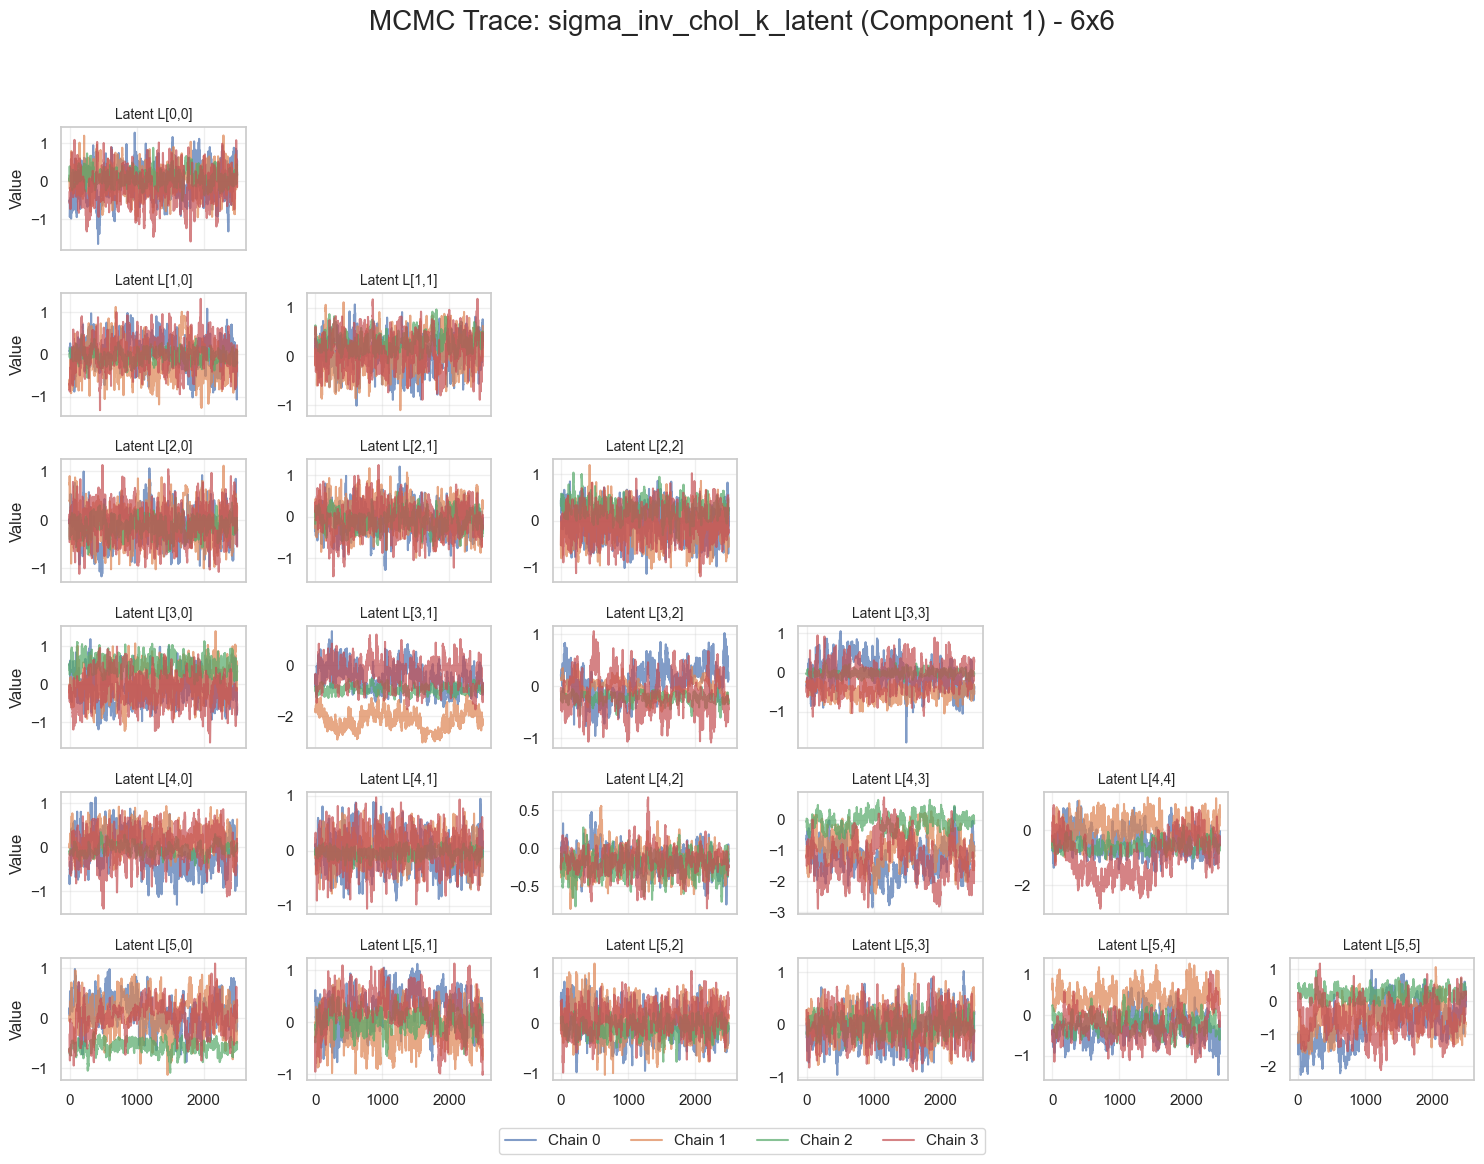


Recovering Covariance Matrices (Sigma_k) from samples...

Plotting Posterior Covariances...


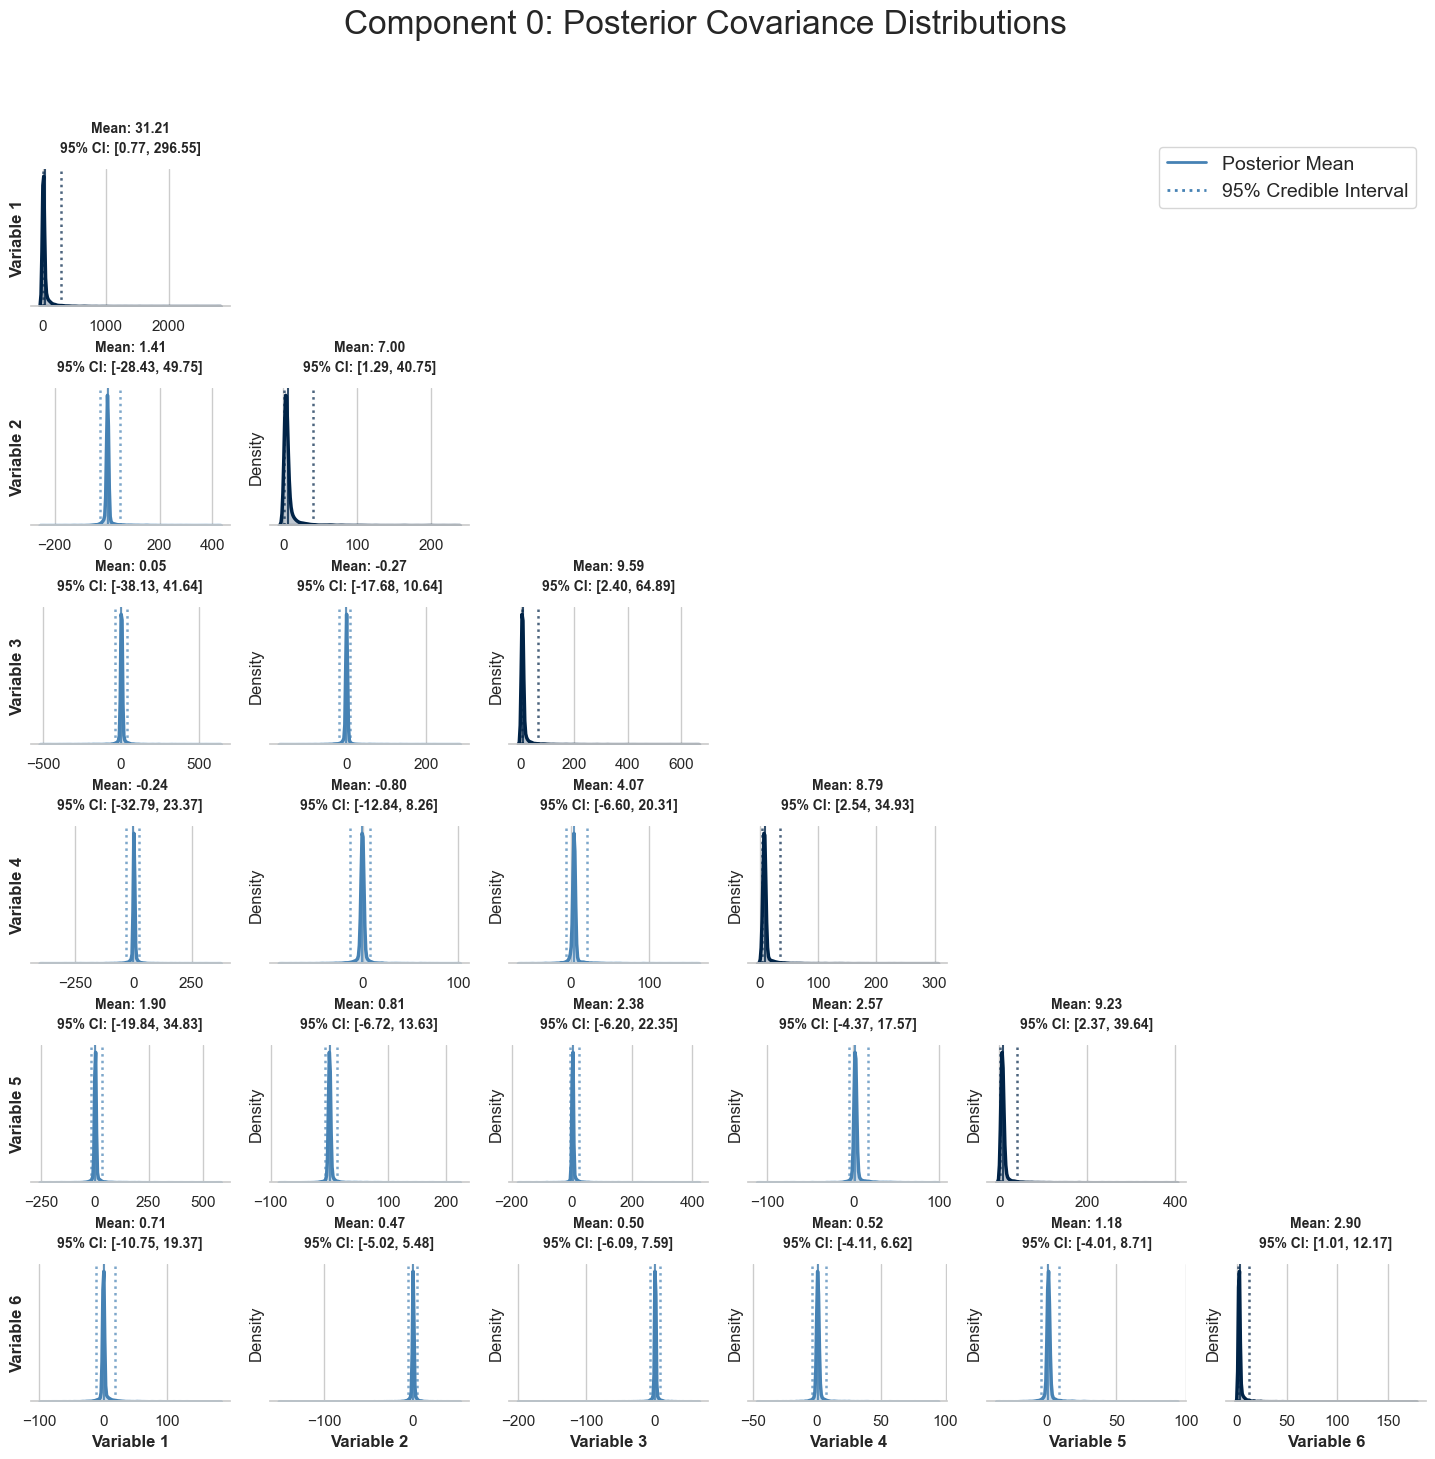

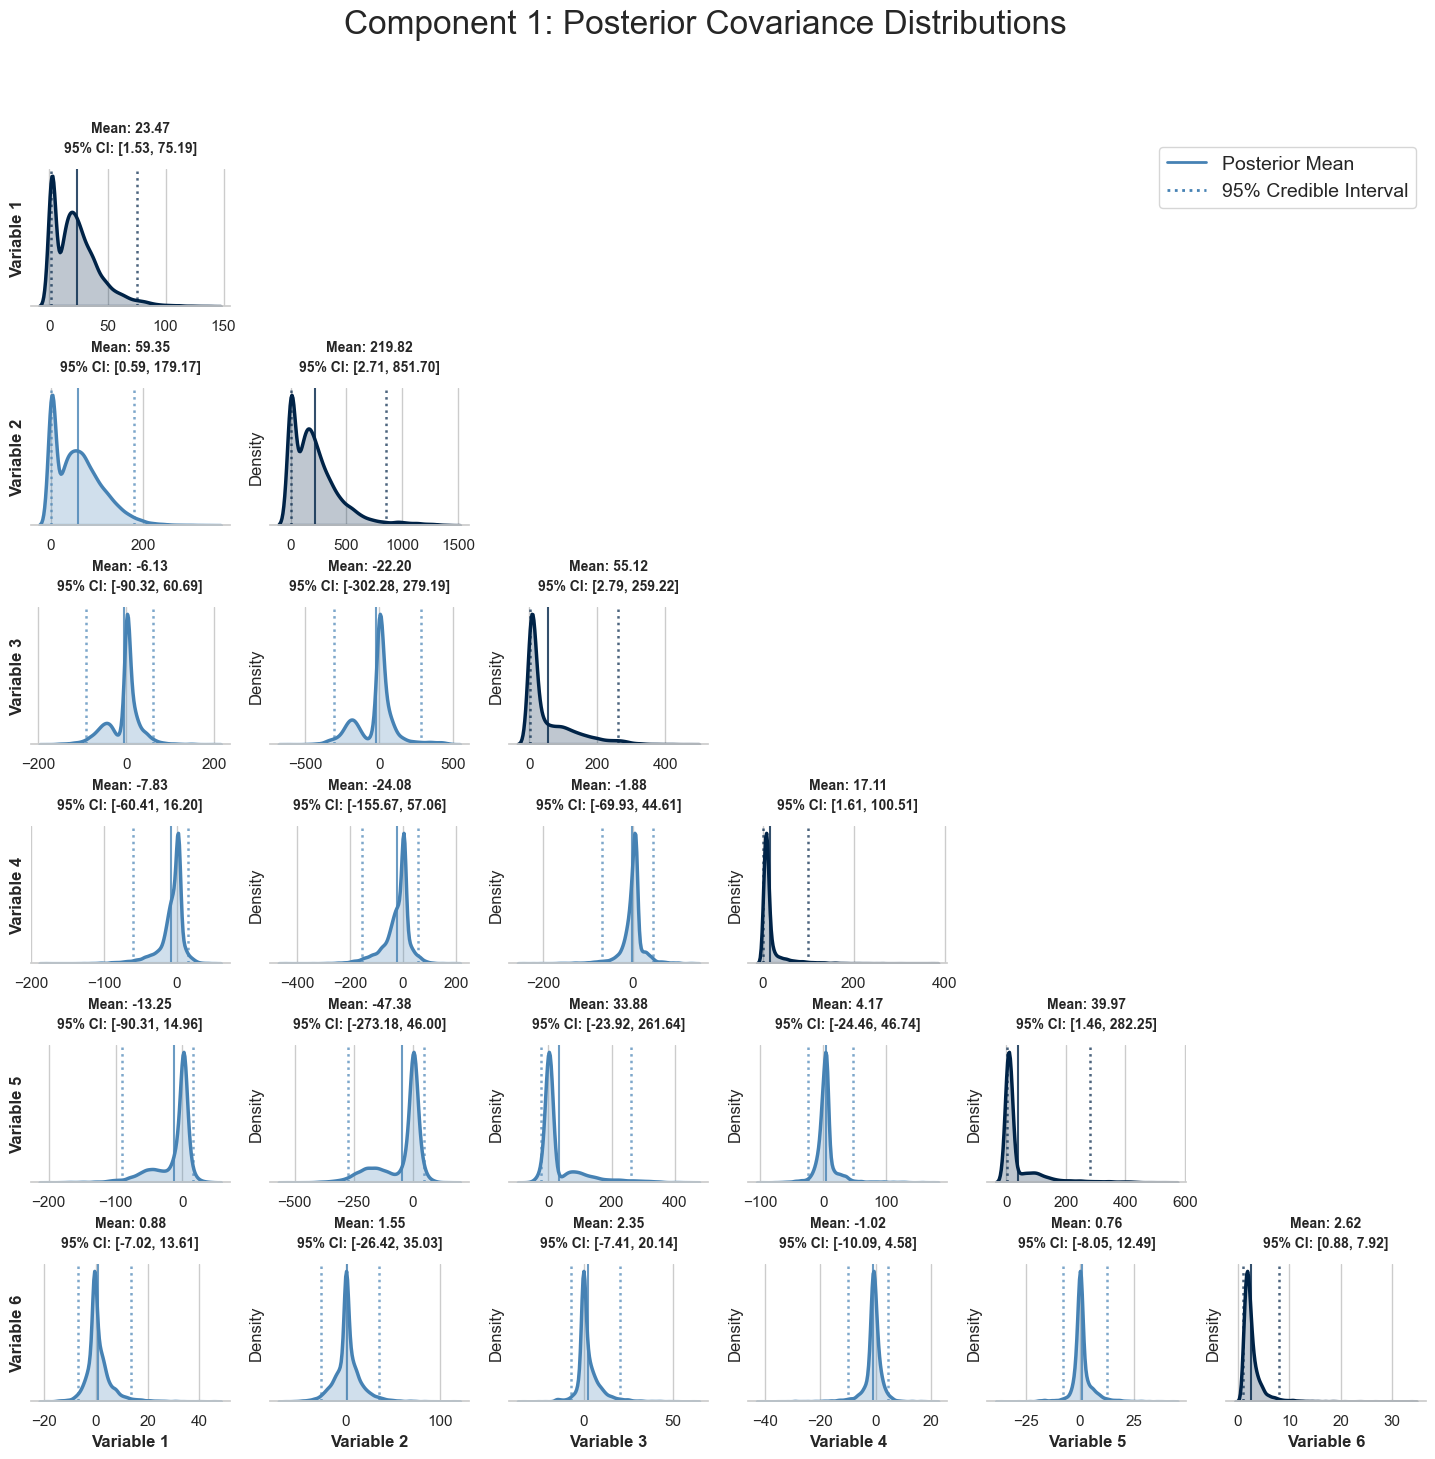

In [31]:
# ── Cell 6 : Diagnostics & Covariance Recovery ────────────────────────────────
print("\n=== MCMC Convergence Summary ===")
# Uncomment the line below to print the full summary (can be quite long)
# summary = gs.Summary(mcmc_results)

def plot_cholesky_traces(samples_dict, n_params, k_idx=0,
                         param_name="sigma_inv_chol_k_latent", figsize=(15, 12)):
    """Plots trace plots for the latent Cholesky factors."""
    latent_samples = samples_dict[param_name][:, :, k_idx, :]
    n_chains, n_draws, n_latent = latent_samples.shape

    fig, axes = plt.subplots(n_params, n_params, figsize=figsize, sharex=True, sharey=False)
    if n_params == 1:
        axes = np.array([[axes]])

    latent_idx = 0
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            if i >= j and latent_idx < n_latent:
                for chain in range(n_chains):
                    ax.plot(latent_samples[chain, :, latent_idx], label=f"Chain {chain}", alpha=0.7)
                ax.set_title(f"Latent L[{i},{j}]", fontsize=10)
                latent_idx += 1
            else:
                ax.axis('off')

            ax.grid(True, alpha=0.3)
            if j == 0:
                ax.set_ylabel("Value")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=n_chains,
               bbox_to_anchor=(0.5, 0.02))
    plt.suptitle(
        f"MCMC Trace: {param_name} (Component {k_idx}) - {n_params}x{n_params}",
        fontsize=20
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

# Extract dimensions from the data_dict
K = int(data_dict["K"])
P = int(data_dict["n_params"])

# 1. Plot Traces for each mixture component
print("\nPlotting Cholesky Traces...")
for k in range(K):
    plot_cholesky_traces(posterior_samples, n_params=P, k_idx=k)


# ── Covariance recovery ────────────────────────────────────────────────────────
print("\nRecovering Covariance Matrices (Sigma_k) from samples...")

bijector_tril = tfb.FillScaleTriL()

def latent_to_sigma(latent_vec):
    """FillScaleTriL latent vector -> Sigma (covariance matrix)."""
    L         = bijector_tril.forward(latent_vec)
    precision = L @ L.T
    return jnp.linalg.inv(precision)

# Vectorize across Chains, Draws, and Components
v_latent_to_sigma = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))
latent_samples_raw = posterior_samples["sigma_inv_chol_k_latent"]
sigma_samples_raw  = v_latent_to_sigma(latent_samples_raw)  # Shape: (chains, draws, K, P, P)


def plot_final_covariance_empirical(samples, component_idx=0):
    """Plots the posterior distributions of the recovered covariance matrix."""
    n_dim = samples.shape[-1]
    fig, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    flattened_samples = samples.reshape(-1, n_dim, n_dim)

    diag_color     = "#002347"
    off_diag_color = "#4682B4"

    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            if j > i:
                ax.axis('off')
                continue

            data_vec      = flattened_samples[:, i, j]
            current_color = diag_color if (i == j) else off_diag_color
            post_mean     = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])

            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            ax.axvline(post_mean, color=current_color, linestyle="-",  lw=1.5, alpha=0.8)
            ax.axvline(ci_low,    color=current_color, linestyle=":",  lw=1.8, alpha=0.7)
            ax.axvline(ci_high,   color=current_color, linestyle=":",  lw=1.8, alpha=0.7)

            title_str = f"Mean: {post_mean:.2f}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)

            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j + 1}", fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"Variable {i + 1}", fontsize=12, fontweight='bold')

    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% Credible Interval')
    ]
    fig.legend(handles=legend_elements, loc='upper right',
               bbox_to_anchor=(0.9, 0.9), fontsize=14, frameon=True)
    plt.suptitle(
        f"Component {component_idx}: Posterior Covariance Distributions",
        fontsize=24, y=0.98
    )
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

# 2. Plot Covariance matrices for each component
print("\nPlotting Posterior Covariances...")
for k in range(K):
    plot_final_covariance_empirical(
        samples=sigma_samples_raw[:, :, k, :, :],
        component_idx=k
    )


=== Detailed Delta Parameter Diagnostics (Goose Style) ===


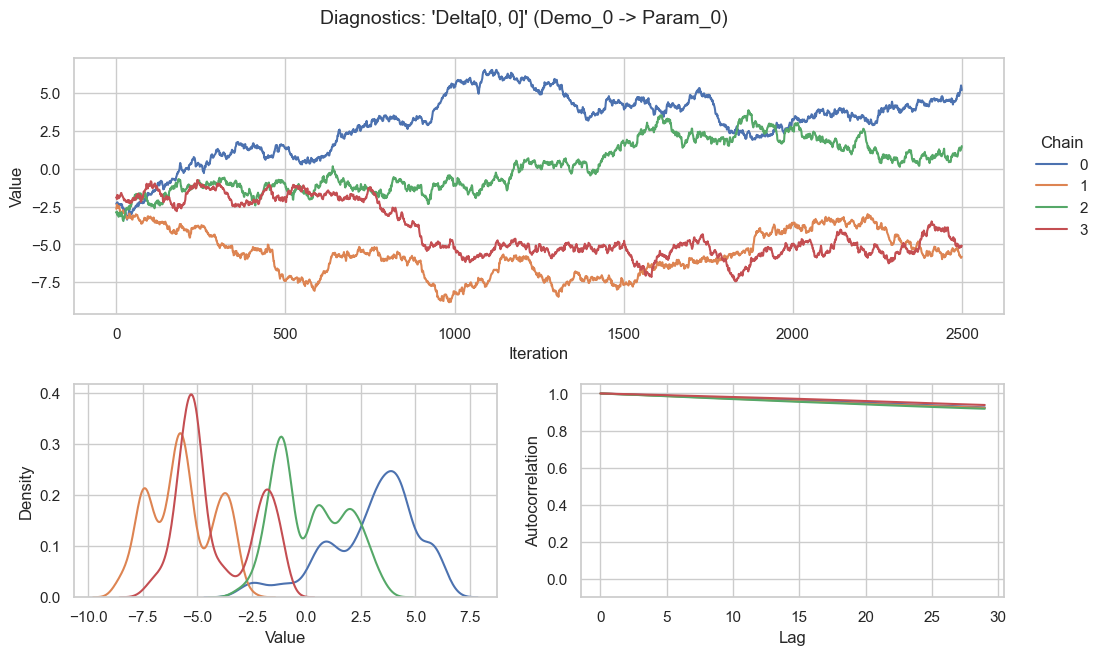

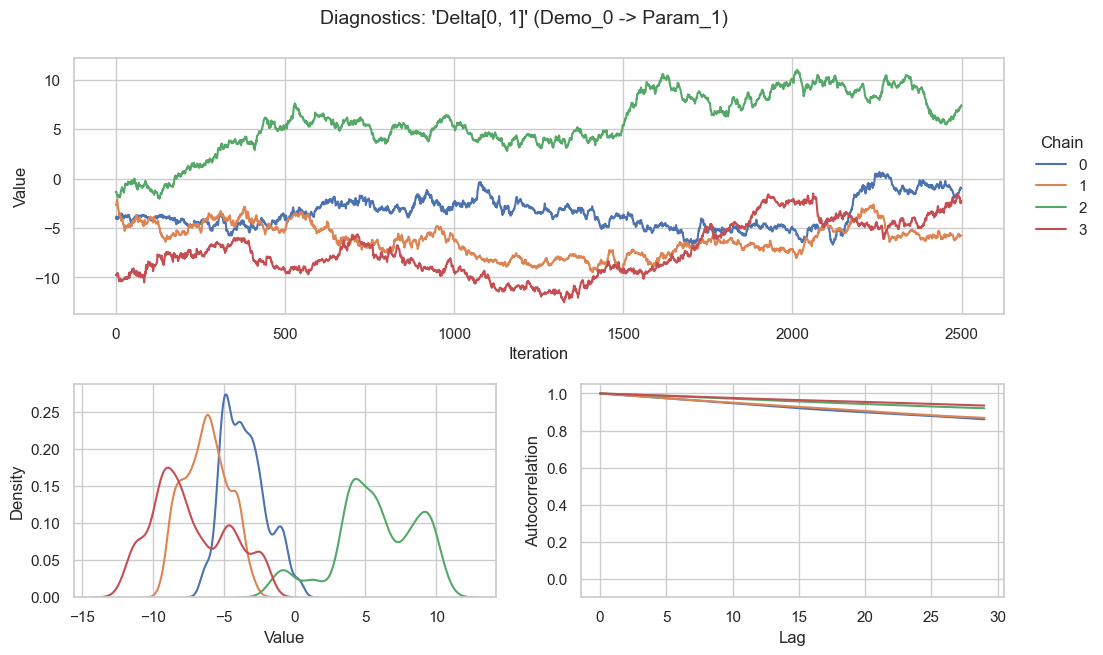

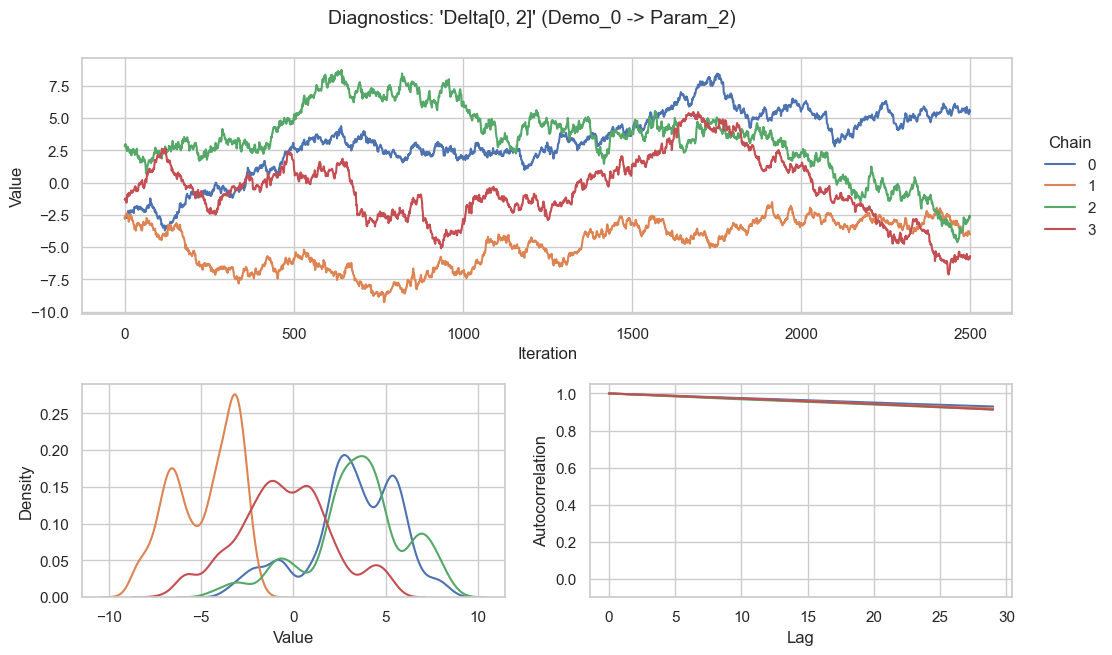

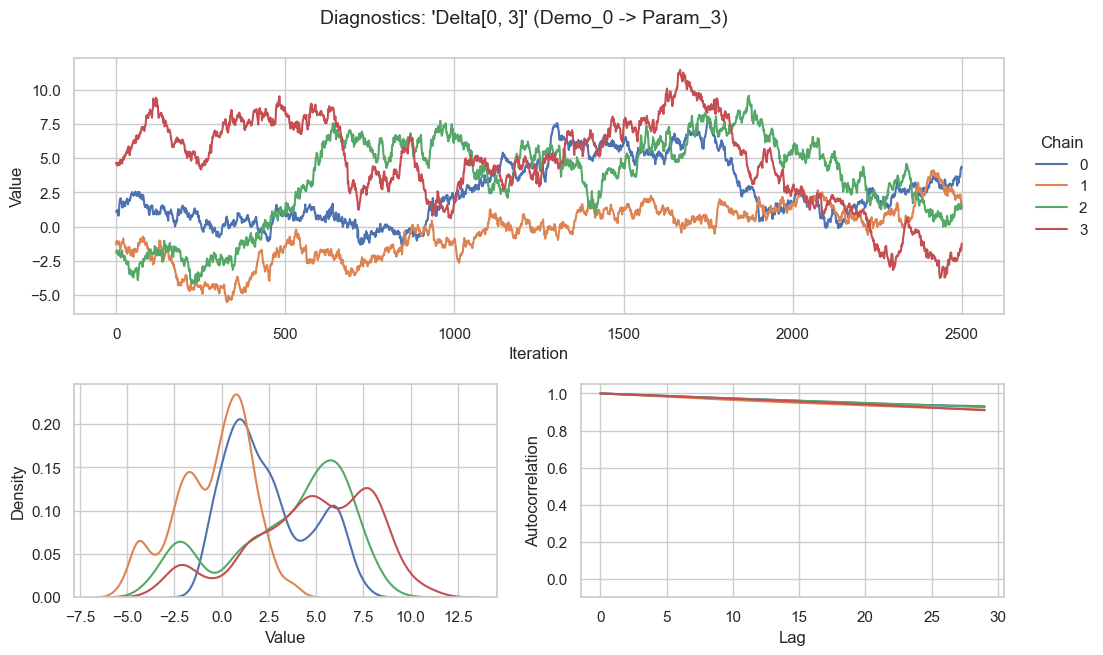

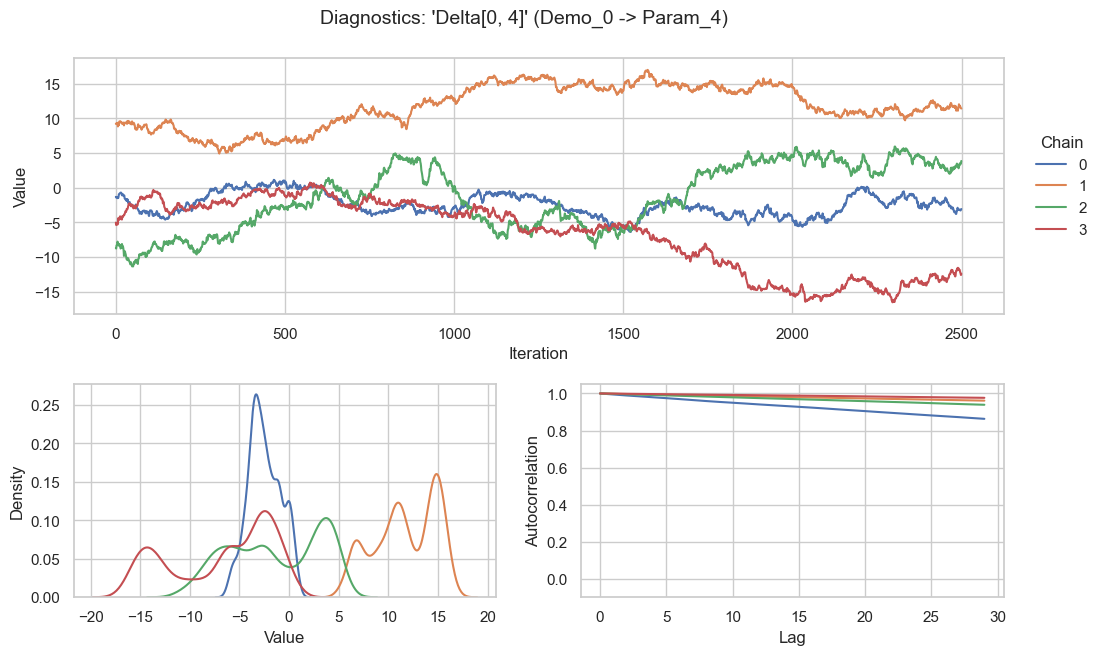

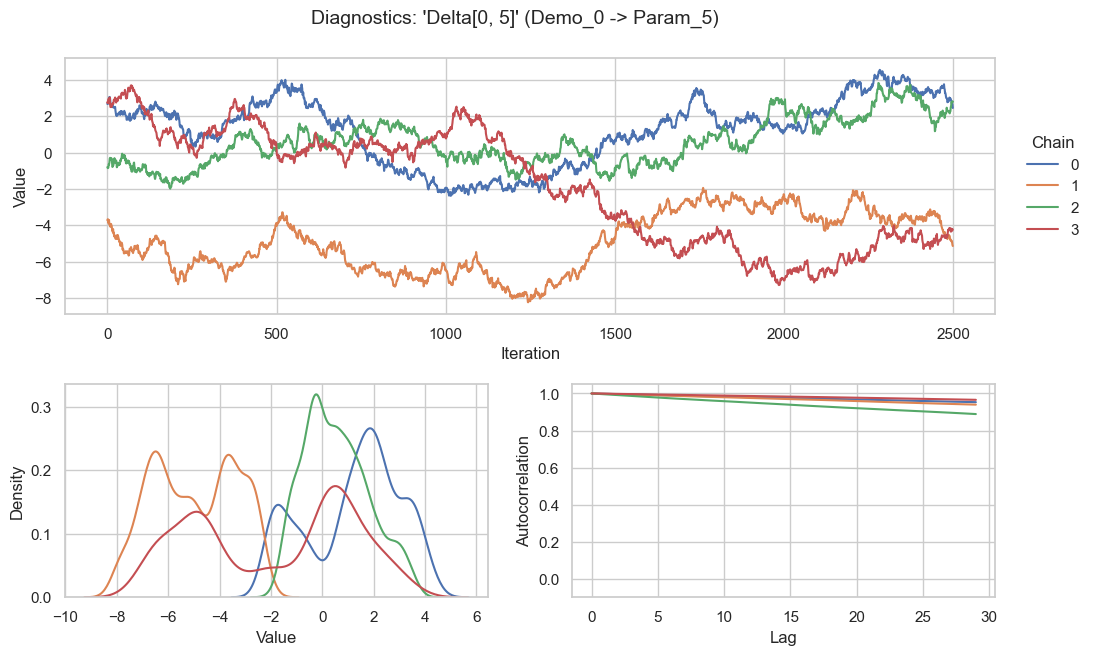

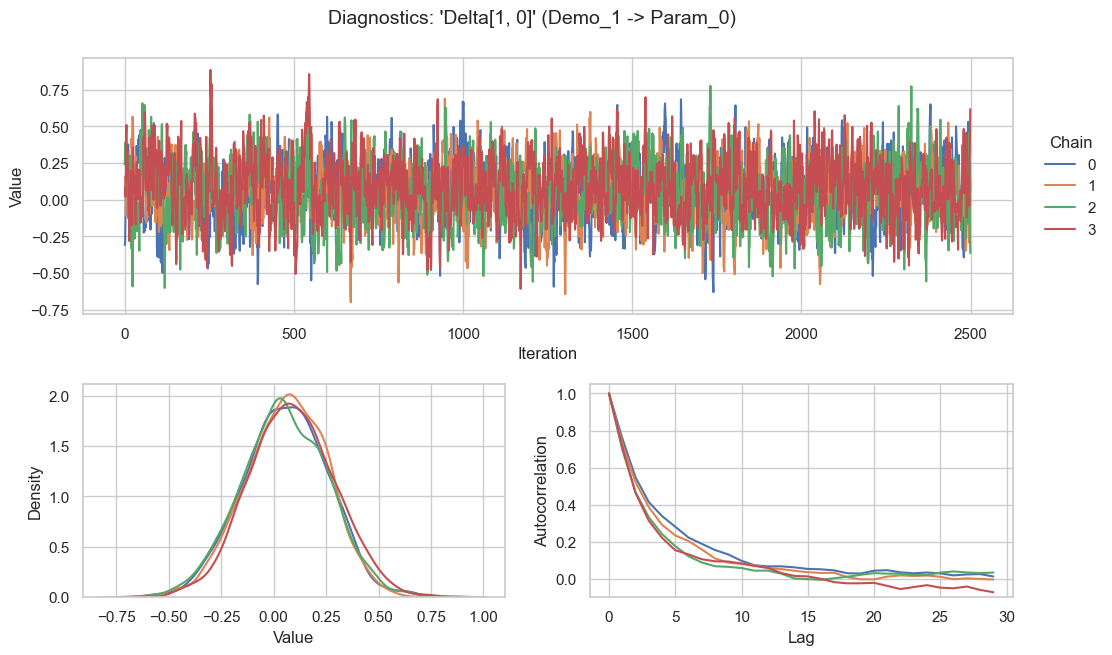

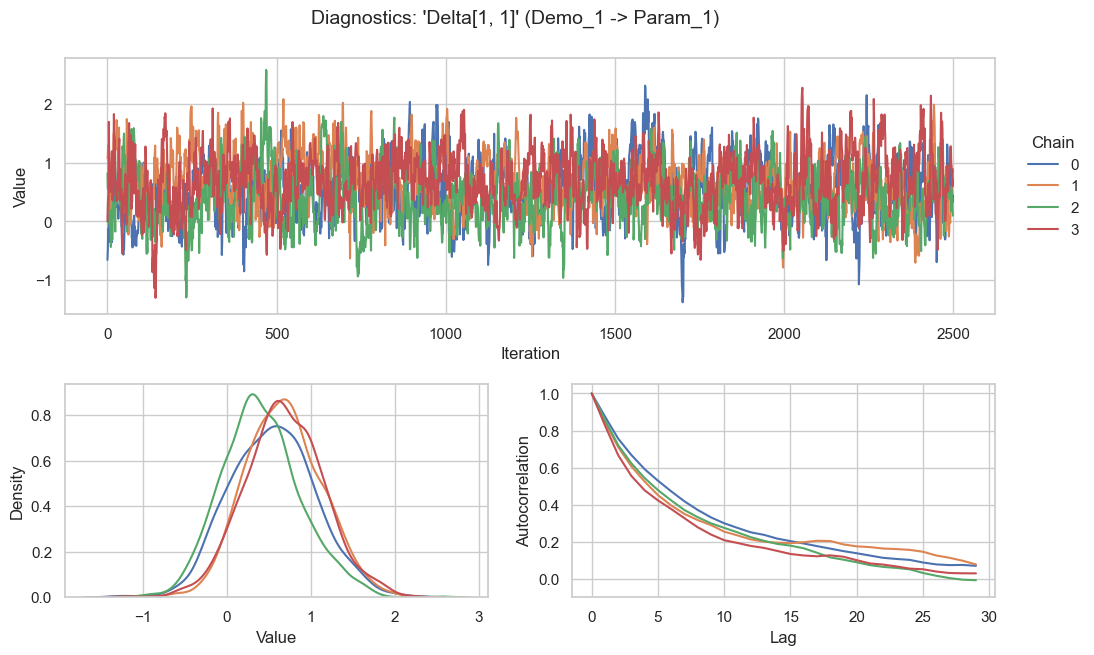

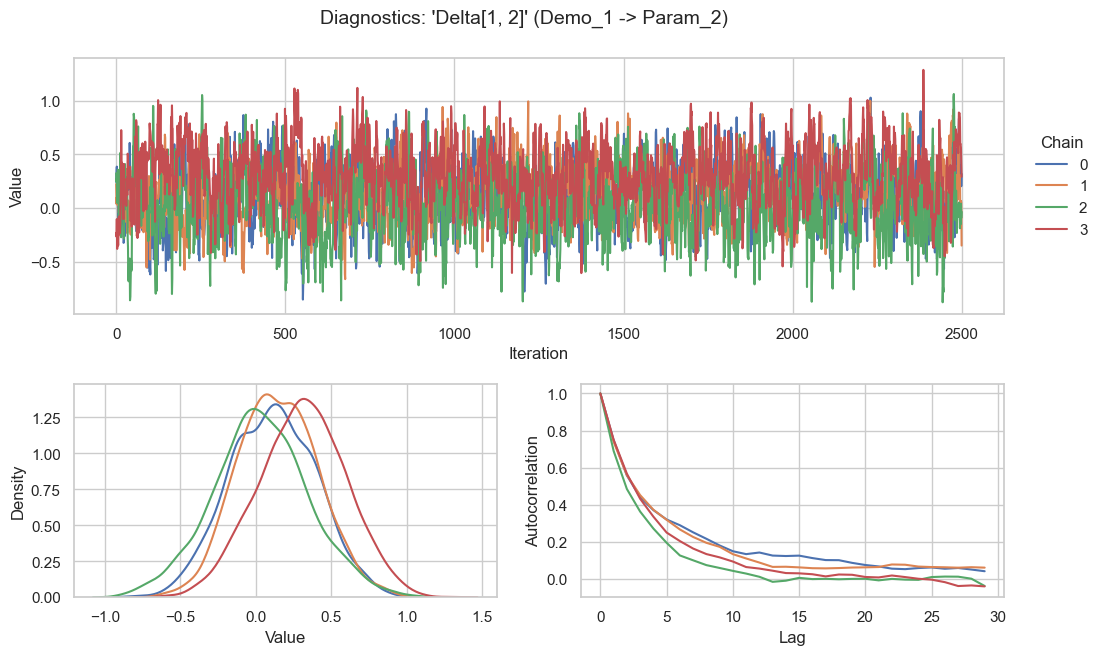

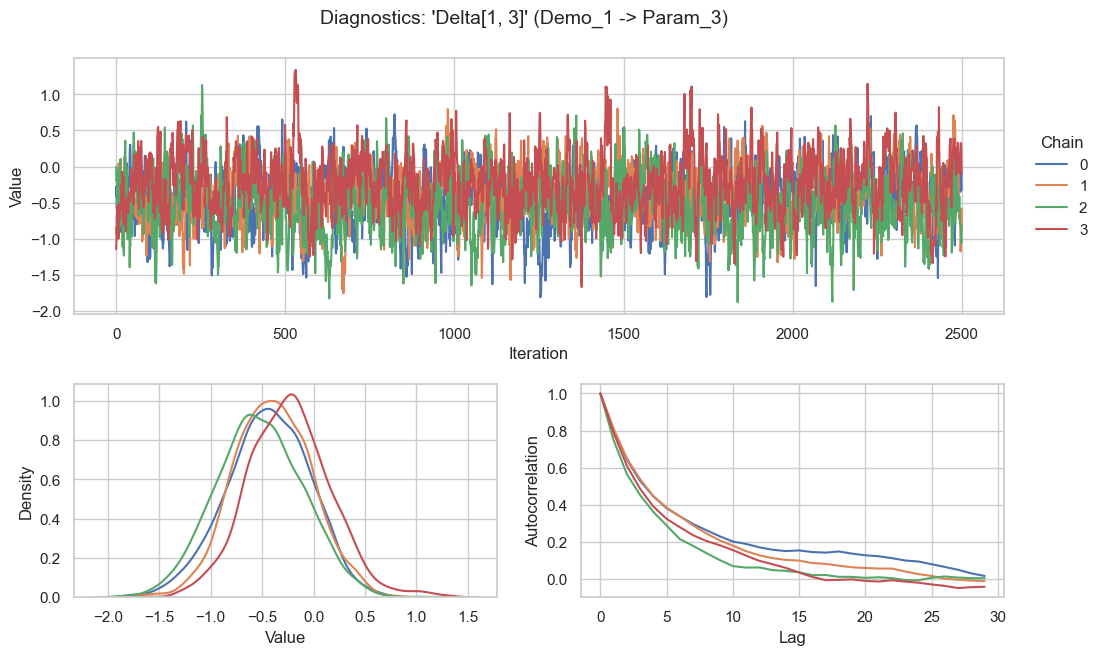

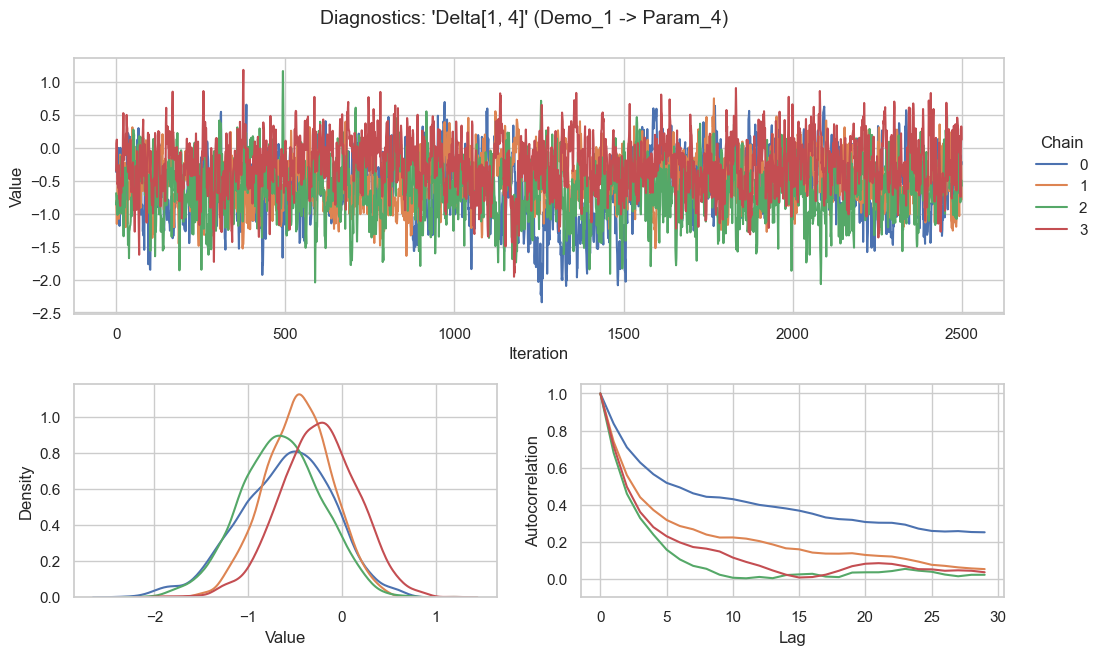

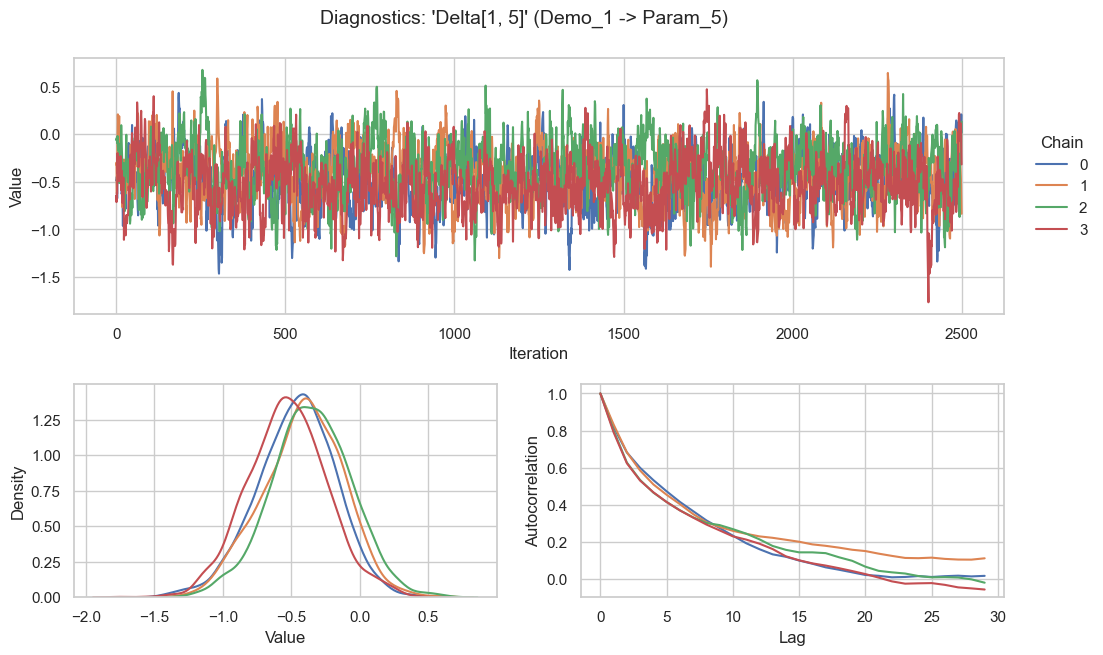

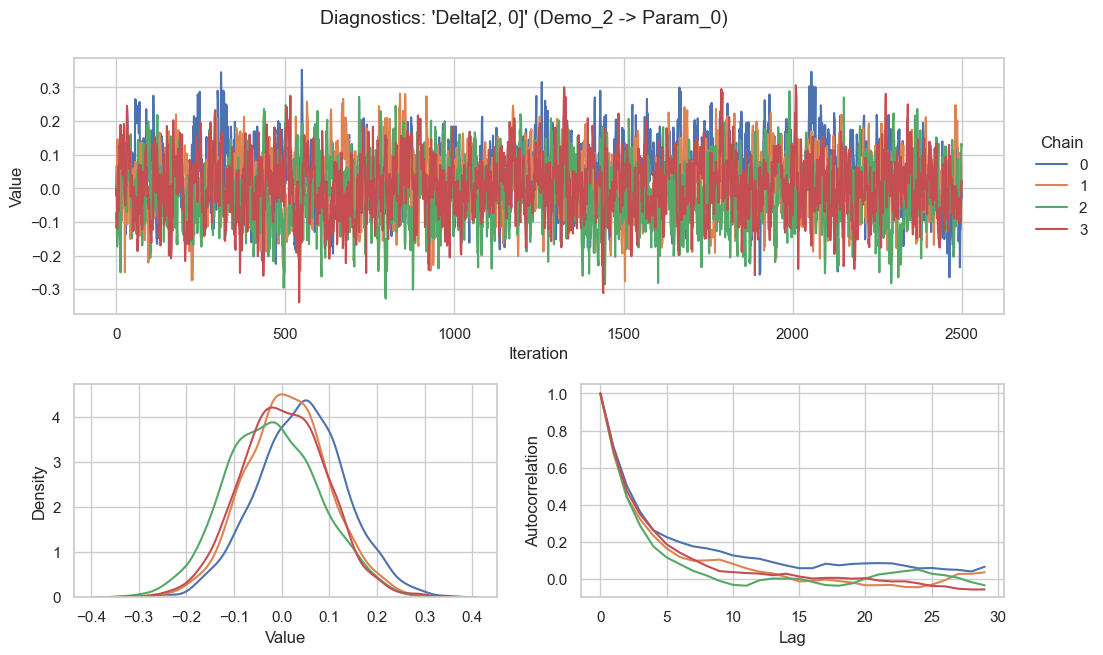

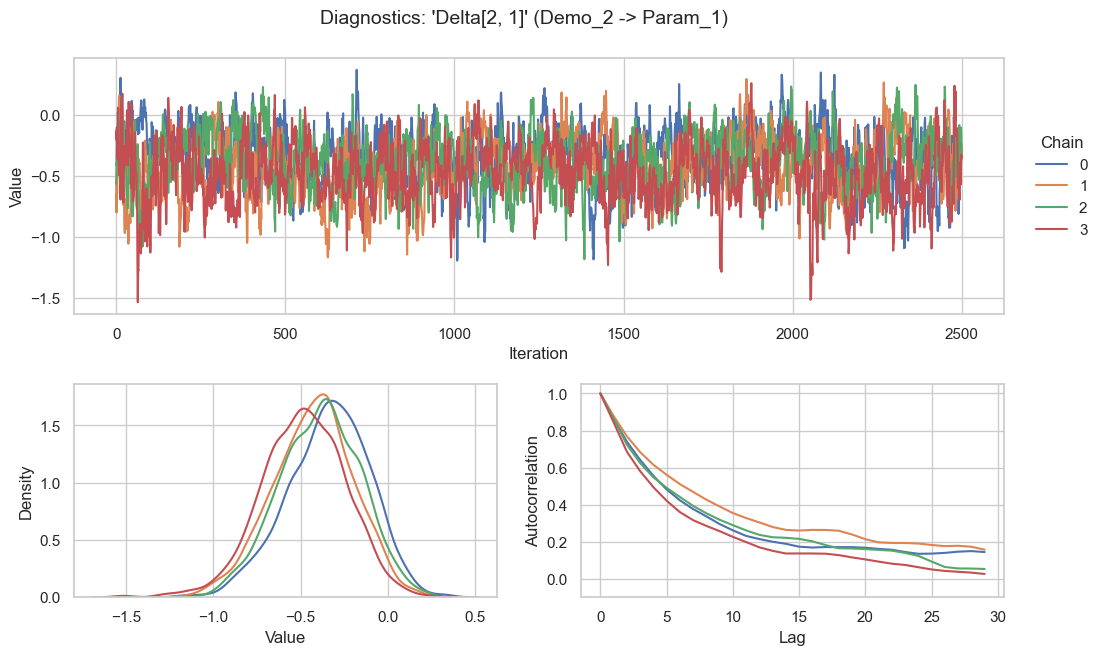

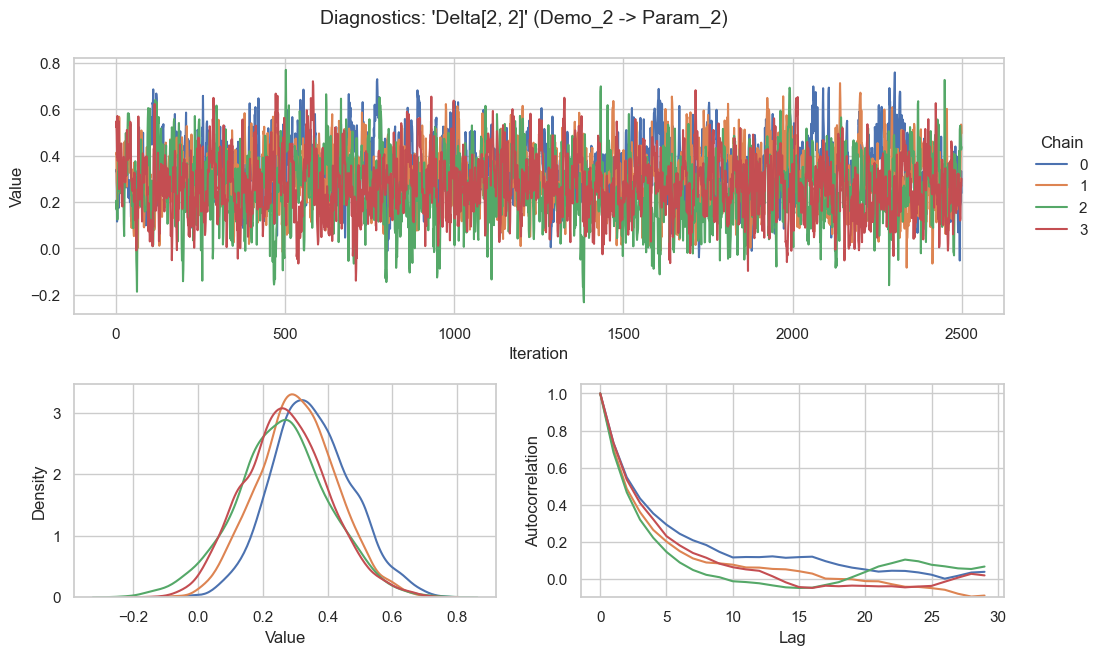

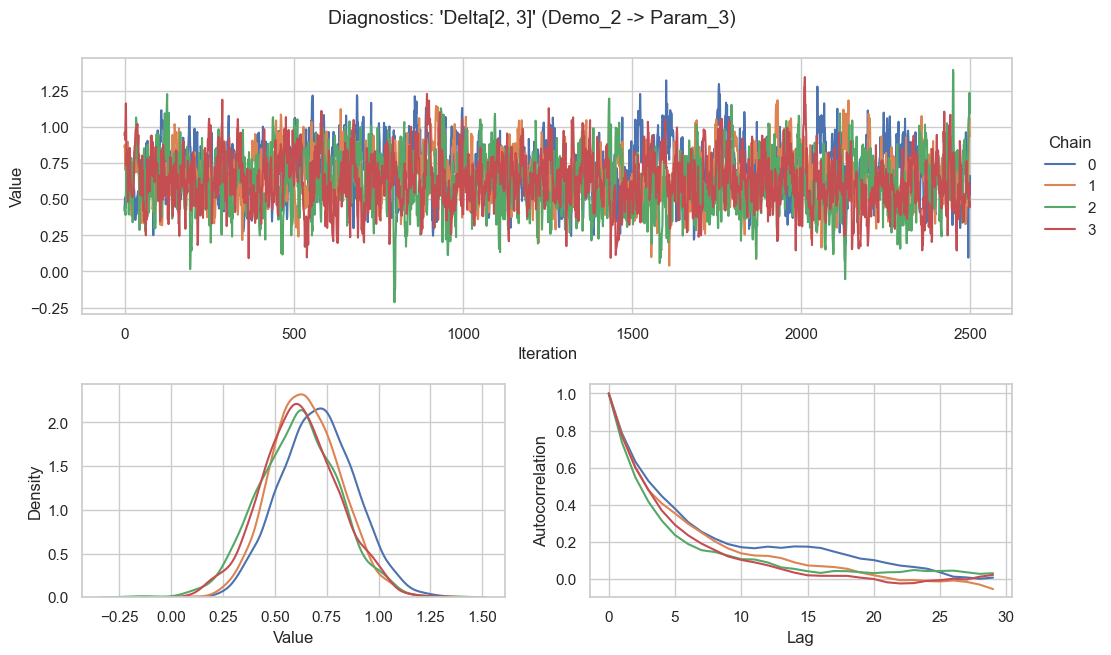

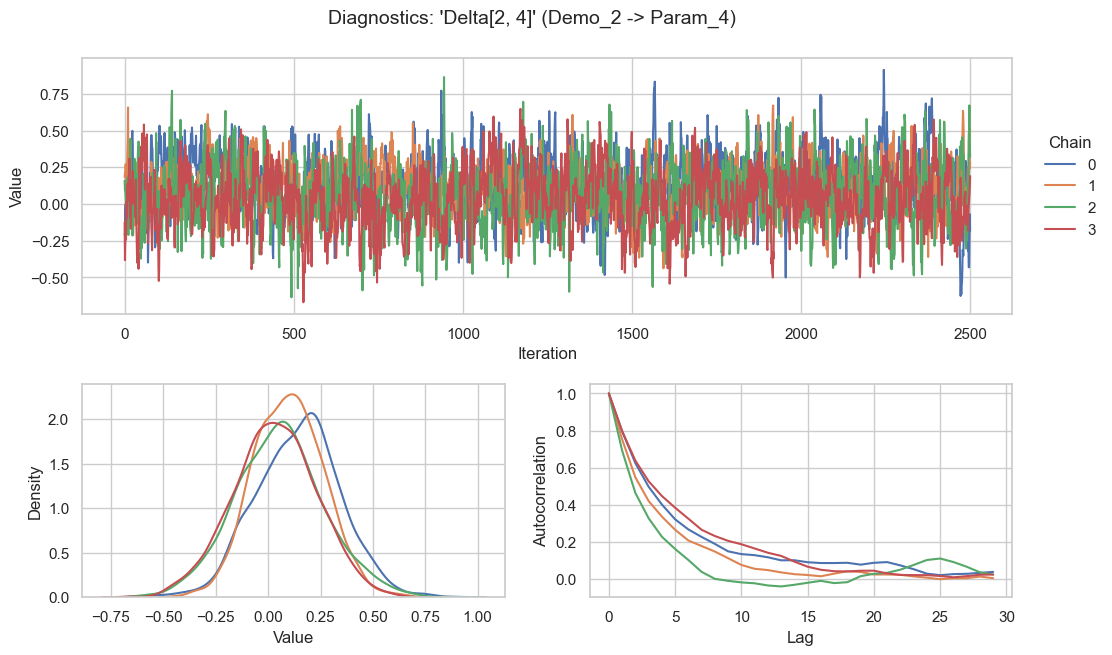

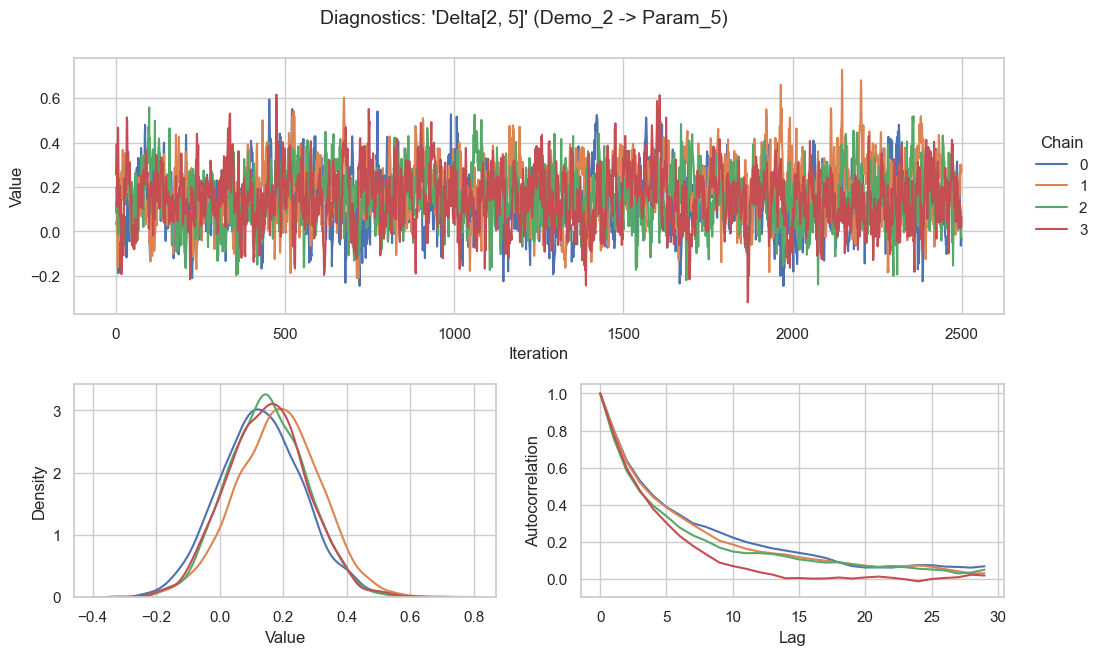

In [32]:
# ── Goose-style chain diagnostics ──────────────────────────────────────────────

def compute_acf(x, nlags=30):
    x_centered = x - np.mean(x)
    norm       = np.sum(x_centered ** 2)
    if norm == 0:
        return np.zeros(nlags)
    acf = np.correlate(x_centered, x_centered, mode='full')
    return (acf[acf.size // 2:] / norm)[:nlags]


def plot_goose_style_diagnostics(delta_array, demo_idx, param_idx,
                                 demo_name, param_name, n_lags=30):
    n_chains = delta_array.shape[0]
    fig = plt.figure(figsize=(12, 7))
    fig.suptitle(
        f"Diagnostics: 'Delta[{demo_idx}, {param_idx}]' ({demo_name} -> {param_name})",
        fontsize=14, y=0.95
    )
    gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1], hspace=0.3, wspace=0.2)

    ax_trace = fig.add_subplot(gs_layout[0, :])
    for chain in range(n_chains):
        ax_trace.plot(delta_array[chain, :, demo_idx, param_idx], label=f"{chain}")
    ax_trace.set_xlabel("Iteration")
    ax_trace.set_ylabel("Value")
    ax_trace.grid(True, alpha=1)
    ax_trace.legend(title="Chain", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    ax_dens = fig.add_subplot(gs_layout[1, 0])
    for chain in range(n_chains):
        sns.kdeplot(delta_array[chain, :, demo_idx, param_idx], ax=ax_dens, fill=False)
    ax_dens.set_xlabel("Value")
    ax_dens.set_ylabel("Density")
    ax_dens.grid(True)

    ax_acf = fig.add_subplot(gs_layout[1, 1])
    for chain in range(n_chains):
        ax_acf.plot(
            compute_acf(delta_array[chain, :, demo_idx, param_idx], nlags=n_lags), alpha=1
        )
    ax_acf.set_xlabel("Lag")
    ax_acf.set_ylabel("Autocorrelation")
    ax_acf.set_ylim(-0.1, 1.05)
    ax_acf.grid(True)
    plt.show()


print("\n=== Detailed Delta Parameter Diagnostics (Goose Style) ===")
raw_delta_samples = posterior_samples_sorted["Delta"]
for i in range(D):
    for j in range(P):
        plot_goose_style_diagnostics(
            raw_delta_samples, demo_idx=i, param_idx=j,
            demo_name=f"Demo_{i}", param_name=f"Param_{j}"
        )


=== Global Parameters (Baseline Means mu_k) Summary Tables ===

--- MCMC Mixture Component 0 ---


,Posterior_Mean,Posterior_Std,CI_2.5%,CI_97.5%
Parameter,,,,
Intercept_Alt1,2.0630,4.4788,-6.534500,10.7912
Intercept_Alt2,4.7511,3.7249,-1.123800,14.6574
Intercept_Alt3,-7.1610,11.9311,-39.665001,5.2976
Intercept_Alt4,-10.1369,7.6405,-32.359501,-0.9507
Intercept_Alt5,-8.5689,15.2738,-50.675201,13.3600
LogPrice,-3.1798,3.3920,-8.480500,2.7759



--- MCMC Mixture Component 1 ---


,Posterior_Mean,Posterior_Std,CI_2.5%,CI_97.5%
Parameter,,,,
Intercept_Alt1,-0.7605,3.6985,-8.318800,4.9436
Intercept_Alt2,-5.9716,6.3892,-23.561300,3.9420
Intercept_Alt3,-13.3901,6.7640,-30.194799,-1.8449
Intercept_Alt4,-13.9601,7.5603,-33.287300,-2.9007
Intercept_Alt5,-9.5516,10.8827,-36.232101,5.6956
LogPrice,-1.6866,3.5764,-7.085800,4.7825



=== Posterior distribution of Delta (Mean & Std) ===


,Intercept_Alt1,Intercept_Alt2,Intercept_Alt3,Intercept_Alt4,Intercept_Alt5,LogPrice
Z_Intercept,-1.66 (3.86),-2.85 (5.59),0.33 (4.12),2.57 (3.35),0.27 (7.91),-1.27 (3.19)
LogIncome_Demeaned,0.07 (0.20),0.58 (0.49),0.15 (0.31),-0.40 (0.42),-0.49 (0.45),-0.44 (0.30)
FamSize_Demeaned,0.01 (0.09),-0.41 (0.24),0.30 (0.14),0.65 (0.19),0.08 (0.20),0.15 (0.13)



Plotting Delta Distributions...


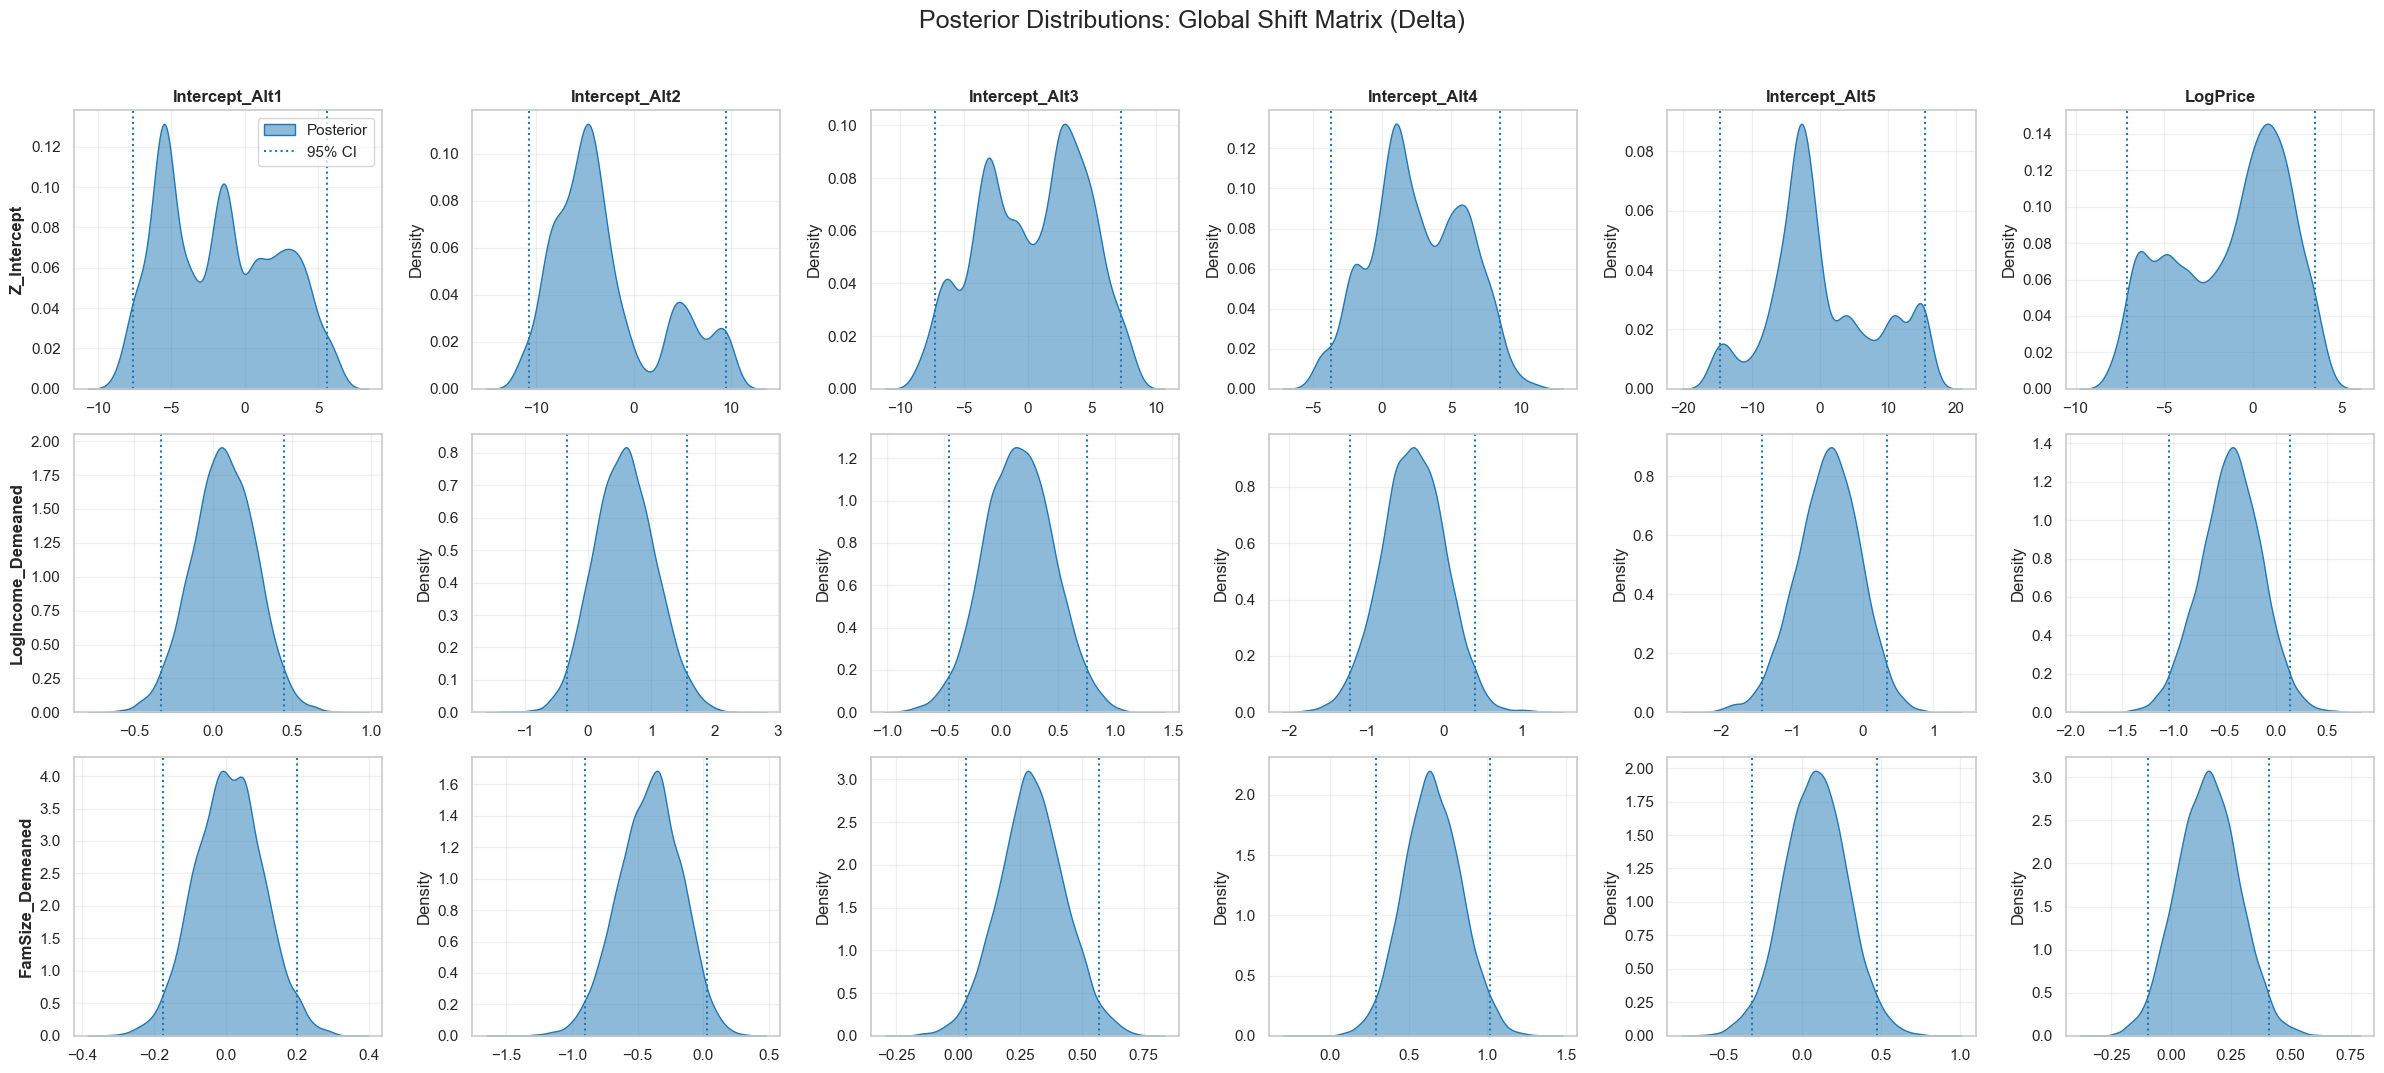

In [34]:
# ── Cell 7 : Global parameters: baseline means & Delta ────────────────────────
import pandas as pd
from IPython.display import display

# Define names based on the data loader construction
param_names = ["Intercept_Alt1", "Intercept_Alt2", "Intercept_Alt3", 
               "Intercept_Alt4", "Intercept_Alt5", "LogPrice"]
demo_names  = ["Z_Intercept", "LogIncome_Demeaned", "FamSize_Demeaned"]

D = len(demo_names)
P = len(param_names)
K = int(data_dict["K"])

def create_summary_table(post_mu, p_names):
    """Creates a summary table for empirical posterior distributions."""
    ci_low = np.percentile(post_mu, 2.5, axis=0)
    ci_high = np.percentile(post_mu, 97.5, axis=0)
    return pd.DataFrame({
        'Parameter':      p_names,
        'Posterior_Mean': post_mu.mean(axis=0),
        'Posterior_Std':  post_mu.std(axis=0),
        'CI_2.5%':        ci_low,
        'CI_97.5%':       ci_high
    }).round(4).set_index("Parameter")

print("\n=== Global Parameters (Baseline Means mu_k) Summary Tables ===")
# Reshape to (Draws, Components, Parameters)
mu_samples_flat = posterior_samples["mu_k"].reshape(-1, K, P)

for k in range(K):
    print(f"\n--- MCMC Mixture Component {k} ---")
    display(create_summary_table(
        post_mu=mu_samples_flat[:, k, :],
        p_names=param_names
    ))


# ── Delta (Demographic Shift Matrix) ──────────────────────────────────────────
def generate_delta_table(delta_draws, p_names, d_names):
    """Formats the Delta matrix showing Mean (Std Dev)."""
    mean = np.mean(delta_draws, axis=0)
    std  = np.std(delta_draws,  axis=0)
    df   = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{mean[i, j]:.2f} ({std[i, j]:.2f})"
    return df

# Delta is global, shape is (Chains, Draws, D, P) -> reshape to (Total_Draws, D, P)
delta_samples_flat = posterior_samples["Delta"].reshape(-1, D, P)

print("\n=== Posterior distribution of Delta (Mean & Std) ===")
display(generate_delta_table(delta_samples_flat, param_names, demo_names))


# ── Plotting Delta Distributions ──────────────────────────────────────────────
def plot_delta_distributions(delta_samples, p_names, d_names):
    """Plots the marginal posterior distributions for each element in Delta."""
    n_demos, n_params = len(d_names), len(p_names)
    fig, axes = plt.subplots(n_demos, n_params, figsize=(4 * n_params, 3.5 * n_demos))

    for d in range(n_demos):
        for p in range(n_params):
            ax      = axes[d, p] if n_demos > 1 else axes[p]
            samples = delta_samples[:, d, p]
            ci_low, ci_high = np.percentile(samples, [2.5, 97.5])

            sns.kdeplot(samples, ax=ax, fill=True, color="#1f77b4", alpha=0.5, label="Posterior")
            ax.axvline(ci_low,  color="#1f77b4", linestyle=":", lw=1.5, label="95% CI")
            ax.axvline(ci_high, color="#1f77b4", linestyle=":", lw=1.5)

            if d == 0:
                ax.set_title(p_names[p], fontweight='bold')
            if p == 0:
                ax.set_ylabel(d_names[d], fontweight='bold')
            ax.grid(True, alpha=0.3)

            if d == 0 and p == 0:
                handles, labels = ax.get_legend_handles_labels()
                unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
                ax.legend(*zip(*unique), loc='upper right')

    plt.suptitle("Posterior Distributions: Global Shift Matrix (Delta)",
                 fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

print("\nPlotting Delta Distributions...")
plot_delta_distributions(delta_samples_flat, param_names, demo_names)


Plotting Empirical Heterogeneity across 313 Households...


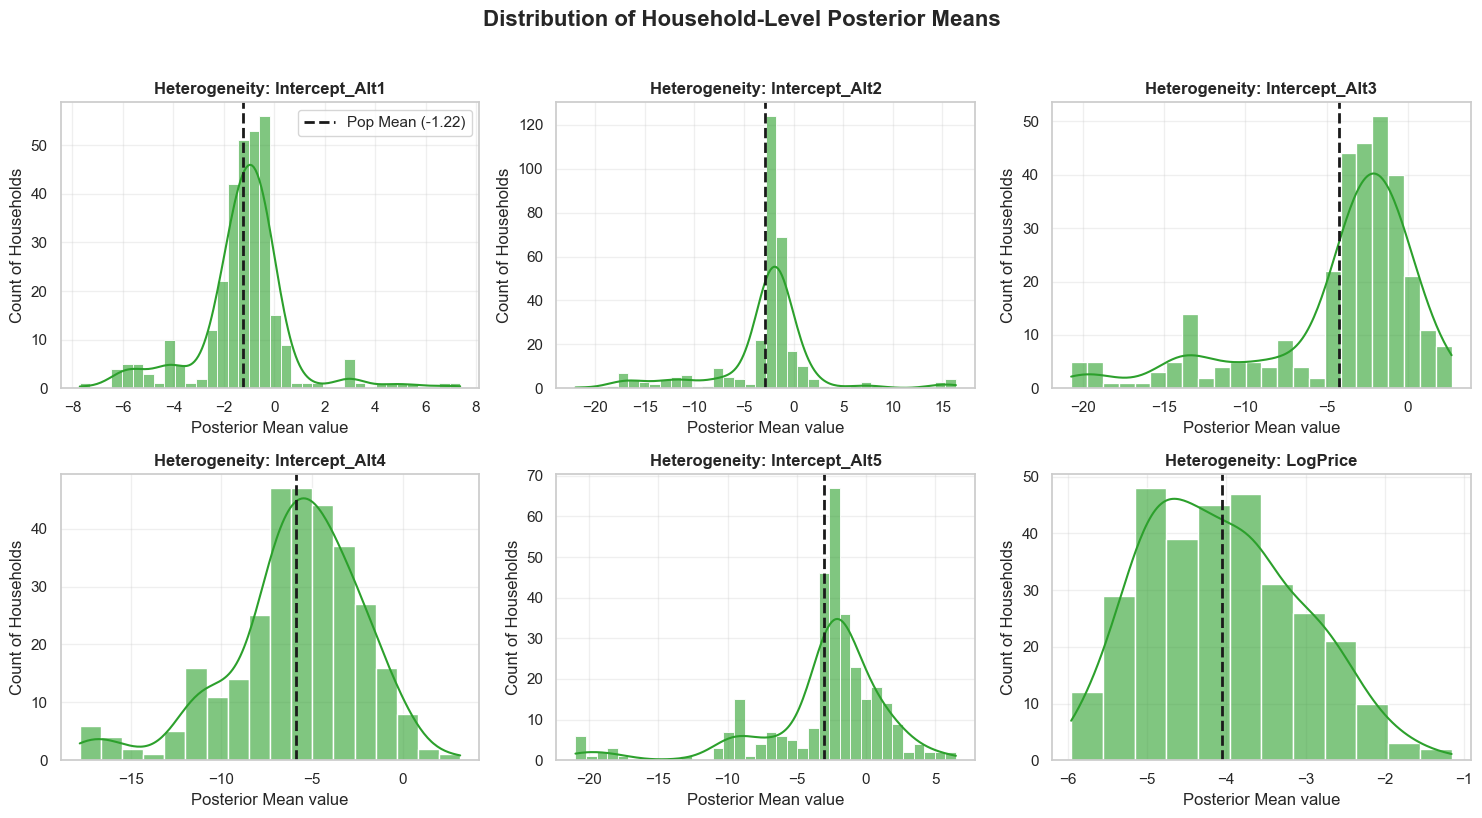


Plotting MCMC Uncertainty for Specific Households...


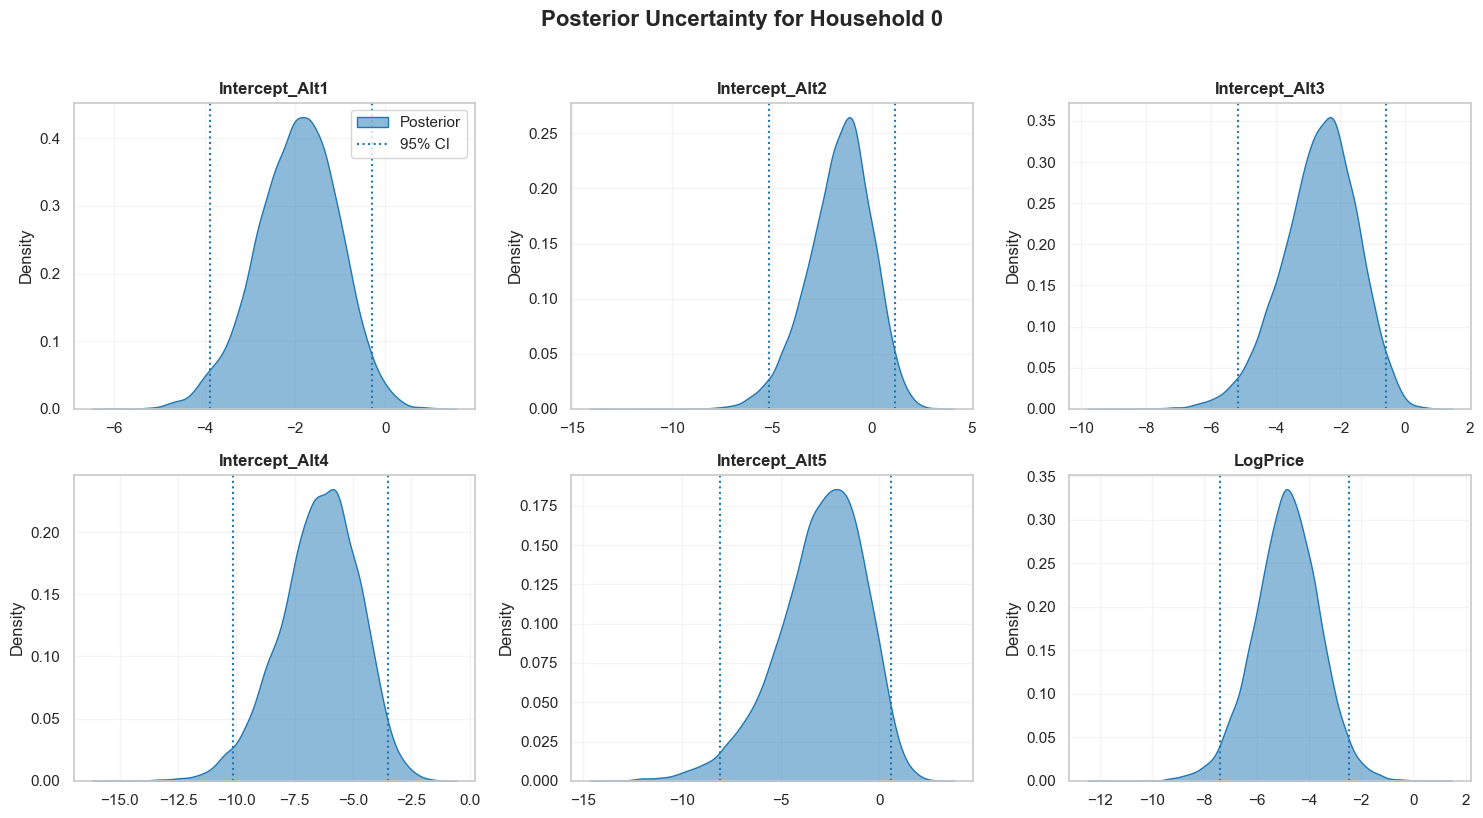

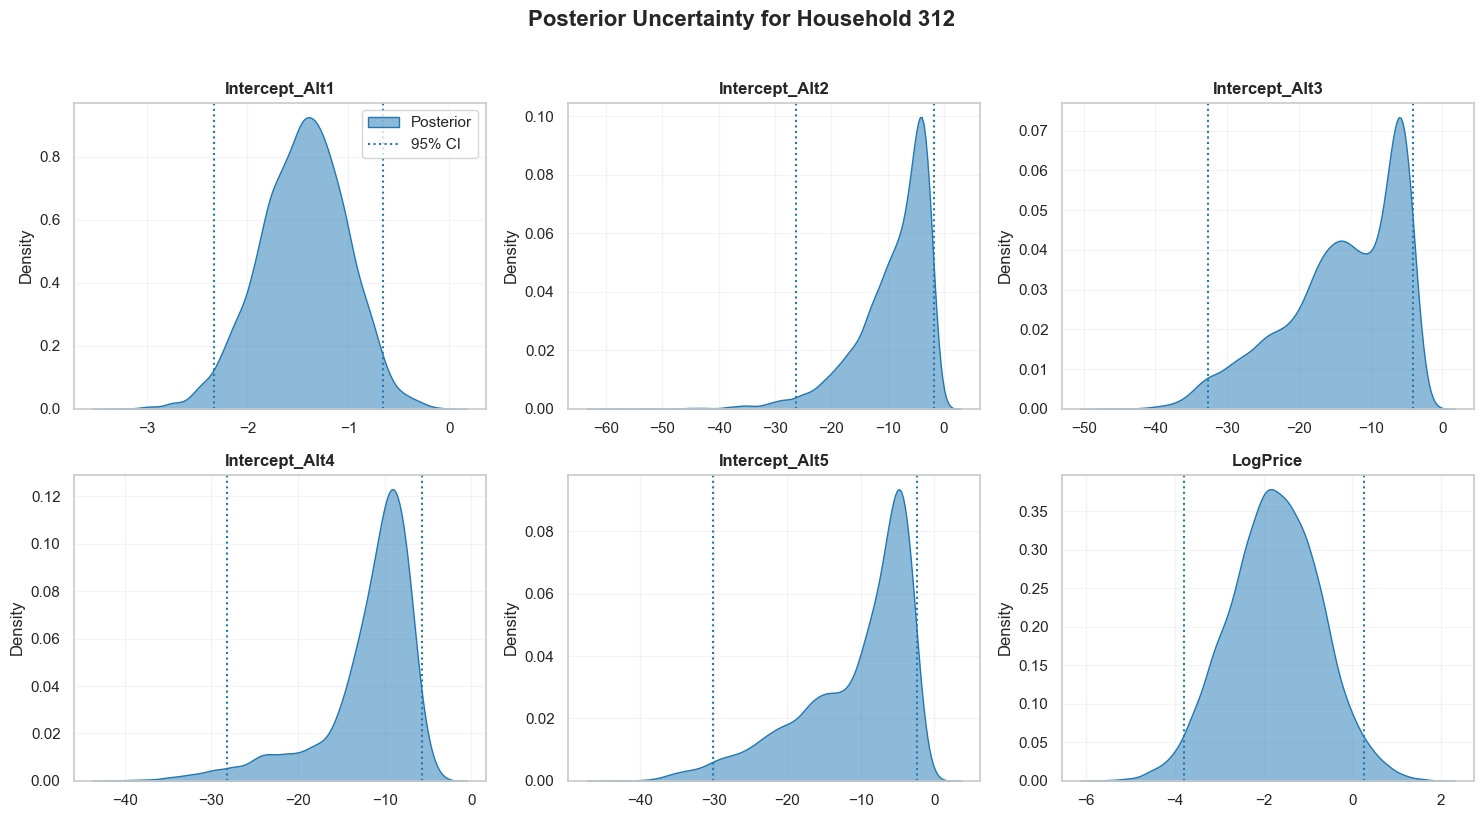

In [35]:
# ── Cell 8 : Household heterogeneity (betas) ──────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract beta samples and reshape to (Total_Draws, n_units, n_params)
n_chains_b, n_draws_b, n_units_b, n_params_b = posterior_samples["beta_i"].shape
liesel_beta_full = posterior_samples["beta_i"].reshape(-1, n_units_b, n_params_b)

# Calculate the posterior mean for each household and each parameter
l_beta_means = np.mean(liesel_beta_full, axis=0)  # Shape: (n_units, n_params)

# ── 1. Population Heterogeneity ───────────────────────────────────────────────
def plot_beta_heterogeneity(beta_means, p_names):
    """Plots the distribution of household-level beta means across the population."""
    cols = 3
    rows = int(np.ceil(len(p_names) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    
    for i, (ax, param) in enumerate(zip(axes.flatten(), p_names)):
        if i >= len(p_names):
            ax.axis('off')
            continue
            
        sns.histplot(beta_means[:, i], kde=True, ax=ax, color='#2ca02c', alpha=0.6)
        
        # Add a line for the overall population mean of these household means
        pop_mean = np.mean(beta_means[:, i])
        ax.axvline(pop_mean, color='k', linestyle='--', lw=2, label=f"Pop Mean ({pop_mean:.2f})")
        
        ax.set_title(f"Heterogeneity: {param}", fontsize=12, fontweight='bold')
        ax.set_xlabel("Posterior Mean value")
        ax.set_ylabel("Count of Households")
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend()

    plt.suptitle("Distribution of Household-Level Posterior Means", y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f"\nPlotting Empirical Heterogeneity across {n_units_b} Households...")
plot_beta_heterogeneity(l_beta_means, param_names)


# ── 2. Individual Household Uncertainty ───────────────────────────────────────
def plot_beta_distributions(samples, p_names, title_prefix, color_l="#1f77b4"):
    """Plots the posterior distribution (MCMC uncertainty) for a single household."""
    cols = 3
    rows = int(np.ceil(len(p_names) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    if len(p_names) == 1:
        axes = np.array([axes])

    for i, (ax, param) in enumerate(zip(axes.flatten(), p_names)):
        if i >= len(p_names):
            ax.axis('off')
            continue

        l_vals  = samples[:, i]
        ci_low, ci_high = np.percentile(l_vals, [2.5, 97.5])

        sns.kdeplot(l_vals, ax=ax, fill=True, color=color_l, alpha=0.5, label="Posterior")
        ax.axvline(ci_low,  color=color_l, linestyle=":", lw=1.5, label="95% CI")
        ax.axvline(ci_high, color=color_l, linestyle=":", lw=1.5)

        ax.set_title(param, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.2)

        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            unique = [(h, l) for j2, (h, l) in enumerate(zip(handles, labels))
                      if l not in labels[:j2]]
            ax.legend(*zip(*unique), loc="upper right")

    plt.suptitle(title_prefix, y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\nPlotting MCMC Uncertainty for Specific Households...")
# Plot the MCMC uncertainty for the very first household in the dataset
plot_beta_distributions(
    liesel_beta_full[:, 0, :], param_names,
    "Posterior Uncertainty for Household 0"
)

# Plot the MCMC uncertainty for the very last household in the dataset
plot_beta_distributions(
    liesel_beta_full[:, -1, :], param_names,
    f"Posterior Uncertainty for Household {n_units_b - 1}"
)